# Football Match Analysis: Argentina vs Australia, 2022 FIFA World Cup Round of 16

**Match:** Argentina vs Australia  
**Competition:** 2022 FIFA World Cup Round of 16  
**Final score:** Argentina 2-1 Australia  
**Match ID:** 3869151  
**Dataset source:** Local processed StatsBomb event data and 360 freeze-frame data from `data/processed`.

This notebook builds a two-team event-data analysis from the local dataset: match scorecard, shot map, xG timeline, passing networks for both teams, multi-player heatmaps, player and team radar comparisons, dangerous passes, xT, zone/territory maps, pitch-control approximation, and progressive action analysis. Each section includes a short reading guide and an observed tactical interpretation.


## Setup and Data Loading

The notebook loads the complete local processed dataset for Argentina vs Australia. Event data powers the standard match plots, while the matching 360 freeze-frame file is normalized for the pitch-control approximation.


In [67]:
# Install only if your environment is missing these libraries:
# !pip install mplsoccer pandas numpy matplotlib scipy ipython

import warnings
from pathlib import Path
from matplotlib.patches import Rectangle

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display
from mplsoccer import Pitch, VerticalPitch
from scipy.ndimage import gaussian_filter

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 11

MATCH_ID = 3869151
EVENTS_PATH = Path('data/processed/match_3869151_events.pkl')
FRAMES_PATH = Path('data/processed/match_3869151_frames.pkl')
MATCH_LABEL = 'Argentina vs Australia'
COMPETITION_LABEL = '2022 FIFA World Cup Round of 16'
MATCH_DATE = '2022-12-03'
FINAL_SCORE = 'Argentina 2-1 Australia'
HOME_TEAM = 'Argentina'
AWAY_TEAM = 'Australia'
TEAMS = [HOME_TEAM, AWAY_TEAM]
PASSING_NETWORK_TEAM = HOME_TEAM
FOCUS_PLAYER = 'Lionel Andrés Messi Cuccittini'
RADAR_PLAYERS = ['Lionel Andrés Messi Cuccittini', 'Jackson Irvine']
HEATMAP_PLAYERS = {
    HOME_TEAM: ['Lionel Andrés Messi Cuccittini', 'Rodrigo Javier De Paul', 'Enzo Fernandez', 'Nicolás Hernán Otamendi'],
    AWAY_TEAM: ['Jackson Irvine', 'Aaron Mooy', 'Kye Rowles', 'Harry Souttar'],
}
TEAM_COLORS = {HOME_TEAM: '#75AADB', AWAY_TEAM: '#FFB81C'}
GOAL = np.array([120.0, 40.0])


In [68]:
def first_coord(value, index):
    """Return one coordinate from a StatsBomb location list, or NaN if missing."""
    if isinstance(value, (list, tuple, np.ndarray)) and len(value) > index:
        return float(value[index])
    return np.nan


def local_data_status(events_path=EVENTS_PATH, frames_path=FRAMES_PATH):
    rows = []
    for label, path in [('events', events_path), ('360 frames', frames_path)]:
        rows.append({
            'dataset': label,
            'path': str(path),
            'exists': path.exists(),
            'rows': len(pd.read_pickle(path)) if path.exists() else 0,
        })
    return pd.DataFrame(rows)


def normalize_frame_rows(frames_df):
    if frames_df.empty:
        return pd.DataFrame(columns=['id', 'visible_area', 'teammate', 'actor', 'keeper', 'location'])

    normalized_rows = []
    for _, frame_event in frames_df.iterrows():
        event_id = frame_event.get('event_uuid')
        visible_area = frame_event.get('visible_area')
        for player in frame_event.get('freeze_frame', []) or []:
            if isinstance(player, dict):
                normalized_rows.append({
                    'id': event_id,
                    'visible_area': visible_area,
                    'teammate': player.get('teammate', False),
                    'actor': player.get('actor', False),
                    'keeper': player.get('keeper', False),
                    'location': player.get('location'),
                })
    return pd.DataFrame(normalized_rows)


def load_local_match_data(events_path=EVENTS_PATH, frames_path=FRAMES_PATH):
    missing = [str(path) for path in [events_path, frames_path] if not path.exists()]
    if missing:
        raise FileNotFoundError('Missing required local dataset file(s): ' + ', '.join(missing))

    events_df = pd.read_pickle(events_path).copy()
    raw_frames = pd.read_pickle(frames_path).copy()
    frames_df = normalize_frame_rows(raw_frames)
    return events_df, frames_df


def add_xy_columns(df, start_col='location', end_col=None):
    df = df.copy()
    if start_col not in df.columns:
        df[start_col] = np.nan
    df['x'] = df[start_col].apply(lambda v: first_coord(v, 0))
    df['y'] = df[start_col].apply(lambda v: first_coord(v, 1))
    if end_col:
        if end_col not in df.columns:
            df[end_col] = np.nan
        df['end_x'] = df[end_col].apply(lambda v: first_coord(v, 0))
        df['end_y'] = df[end_col].apply(lambda v: first_coord(v, 1))
    return df


def distance_to_goal(x, y):
    return np.sqrt((120 - x) ** 2 + (40 - y) ** 2)


def safe_bool(series):
    return series.fillna(False).astype(bool) if series is not None else False


def player_events(player_name, source_events=None):
    source_events = events if source_events is None and 'events' in globals() else source_events
    if source_events is None or source_events.empty:
        return pd.DataFrame()
    exact = source_events[source_events['player'].eq(player_name)].copy()
    if not exact.empty:
        return exact
    pattern = str(player_name).casefold()
    return source_events[source_events['player'].fillna('').str.casefold().str.contains(pattern, regex=False)].copy()


def player_label(player_name):
    matches = player_events(player_name)
    if not matches.empty:
        return matches['player'].dropna().iloc[0]
    return player_name


def display_player_name(player_name):
    resolved = player_label(player_name)
    parts = resolved.split()
    return ' '.join(parts[:1] + parts[-1:]) if len(parts) > 1 else resolved


def load_xt_grid(path='data/processed/xT_16x12_surface.csv'):
    xt_table = pd.read_csv(path)
    grid = (
        xt_table.pivot(index='y_idx', columns='x_idx', values='xT')
        .sort_index(axis=0)
        .sort_index(axis=1)
        .fillna(0)
    )
    return grid.to_numpy()


def xt_value(x, y, grid):
    if pd.isna(x) or pd.isna(y):
        return np.nan
    x_idx = int(np.clip(np.floor(x / 120 * grid.shape[1]), 0, grid.shape[1] - 1))
    y_idx = int(np.clip(np.floor(y / 80 * grid.shape[0]), 0, grid.shape[0] - 1))
    return float(grid[y_idx, x_idx])


def normalize_metric_values(df):
    normalized = df.copy().astype(float)
    for column in normalized.columns:
        max_value = normalized[column].max()
        normalized[column] = normalized[column] / max_value if max_value > 0 else 0
    return normalized



def pitch_cell_indices(x, y, grid):
    if pd.isna(x) or pd.isna(y):
        return np.nan, np.nan
    x_idx = int(np.clip(np.floor(x / 120 * grid.shape[1]), 0, grid.shape[1] - 1))
    y_idx = int(np.clip(np.floor(y / 80 * grid.shape[0]), 0, grid.shape[0] - 1))
    return x_idx, y_idx


def plot_xt_surface(ax, grid, title, cmap='RdYlBu_r', vmax=None, colorbar=True, label='xT value'):
    pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
    pitch.draw(ax=ax)
    extent = [0, 120, 80, 0]
    vmax = grid.max() if vmax is None else vmax
    image = ax.imshow(grid, extent=extent, origin='upper', cmap=cmap, vmin=0, vmax=vmax, alpha=0.82)
    ax.set_title(title)
    if colorbar:
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label=label)
    return image


def xt_destination_matrix(actions, grid, value_col='xT_gain'):
    matrix = np.zeros_like(grid, dtype=float)
    for _, row in actions.dropna(subset=['end_x', 'end_y']).iterrows():
        x_idx, y_idx = pitch_cell_indices(row['end_x'], row['end_y'], grid)
        if pd.notna(x_idx) and pd.notna(y_idx):
            matrix[int(y_idx), int(x_idx)] += max(float(row.get(value_col, 0) or 0), 0)
    return matrix


def compute_carry_metrics(events_df):
    carry_df = add_xy_columns(events_df[events_df['type'] == 'Carry'].copy(), end_col='carry_end_location')
    carry_df = carry_df.dropna(subset=['x', 'y', 'end_x', 'end_y', 'duration']).copy()
    carry_df['dx_m'] = (carry_df['end_x'] - carry_df['x']) * 105 / 120
    carry_df['dy_m'] = (carry_df['end_y'] - carry_df['y']) * 68 / 80
    carry_df['distance_m'] = np.sqrt(carry_df['dx_m'] ** 2 + carry_df['dy_m'] ** 2)
    carry_df = carry_df[(carry_df['duration'] >= 0.2) & (carry_df['distance_m'] >= 1)].copy()
    carry_df['speed_mps'] = carry_df['distance_m'] / carry_df['duration']
    return carry_df


def build_match_scorecard(events_df):
    shots_df = events_df[events_df['type'] == 'Shot'].copy()
    passes_df = add_xy_columns(events_df[events_df['type'] == 'Pass'].copy(), end_col='pass_end_location')
    carries_df = events_df[events_df['type'] == 'Carry'].copy()
    completed = passes_df['pass_outcome'].isna()
    final_third_entry = completed & (passes_df['x'] < 80) & (passes_df['end_x'] >= 80)

    rows = []
    for team in TEAMS:
        team_shots = shots_df[shots_df['team'] == team]
        team_passes = passes_df[passes_df['team'] == team]
        rows.append({
            'Team': team,
            'Score': 2 if team == HOME_TEAM else 1,
            'Shot Goals': int(team_shots['shot_outcome'].eq('Goal').sum()),
            'Shots': len(team_shots),
            'xG': team_shots['shot_statsbomb_xg'].fillna(0).sum(),
            'Events': int((events_df['team'] == team).sum()),
            'Passes': len(team_passes),
            'Completed Passes': int(team_passes['pass_outcome'].isna().sum()),
            'Carries': int((carries_df['team'] == team).sum()),
            'Final Third Entries': int(final_third_entry[passes_df['team'] == team].sum()),
        })
    return pd.DataFrame(rows).set_index('Team')


In [69]:
selected_match = pd.DataFrame([{
    'match_id': MATCH_ID,
    'competition': COMPETITION_LABEL,
    'match': MATCH_LABEL,
    'home_team': HOME_TEAM,
    'away_team': AWAY_TEAM,
    'home_score': 2,
    'away_score': 1,
    'match_date': MATCH_DATE,
    'events_file': str(EVENTS_PATH),
    'frames_file': str(FRAMES_PATH),
}])
selected_match


,match_id,competition,match,home_team,away_team,home_score,away_score,match_date,events_file,frames_file
0,3869151,2022 FIFA World Cup Round of 16,Argentina vs Australia,Argentina,Australia,2,1,2022-12-03,data\processed\match_3869151_events.pkl,data\processed\match_3869151_frames.pkl


In [70]:
display(local_data_status(EVENTS_PATH, FRAMES_PATH))
events, frames = load_local_match_data(EVENTS_PATH, FRAMES_PATH)

print(f'Events loaded: {len(events):,}')
print(f'360 freeze-frame player rows normalized: {len(frames):,}')
print(events['team'].value_counts(dropna=False))
events[['minute', 'second', 'team', 'player', 'type']].head()


,dataset,path,exists,rows
0,events,data\processed\match_3869151_events.pkl,True,4150
1,360 frames,data\processed\match_3869151_frames.pkl,True,3482


Events loaded: 4,150
360 freeze-frame player rows normalized: 58,549
team
Argentina    2459
Australia    1691
Name: count, dtype: int64


,minute,second,team,player,type
0,0,0,Argentina,NaN,Starting XI
1,0,0,Australia,NaN,Starting XI
2,0,0,Argentina,NaN,Half Start
3,0,0,Australia,NaN,Half Start
4,45,0,Australia,NaN,Half Start


## Match Scorecard

This scorecard gives the high-level context before the visual analysis. **Shot Goals** counts goals that appear as shot outcomes in the event data; Australia’s score is 1 because the match finished 2-1, but its shot-goal count is 0 because the Australian goal was recorded through Argentina’s own-goal/deflection sequence rather than as an Australian shot goal.


In [71]:
scorecard = build_match_scorecard(events)
scorecard.style.format({'xG': '{:.2f}'})


,Score,Shot Goals,Shots,xG,Events,Passes,Completed Passes,Carries,Final Third Entries
Team,,,,,,,,,
Argentina,2,2,14,1.48,2459,728,646,646,45
Australia,1,0,5,0.43,1691,478,384,320,23


## 1. Shot Map

**How to read this chart:** each marker is one shot, marker size scales with StatsBomb xG, and black outlines mark goals. The same pitch is used for both teams so shot location and chance quality can be compared directly.


,Shots,xG,Shot_Goals
team,,,
Argentina,14,1.48,2
Australia,5,0.43,0


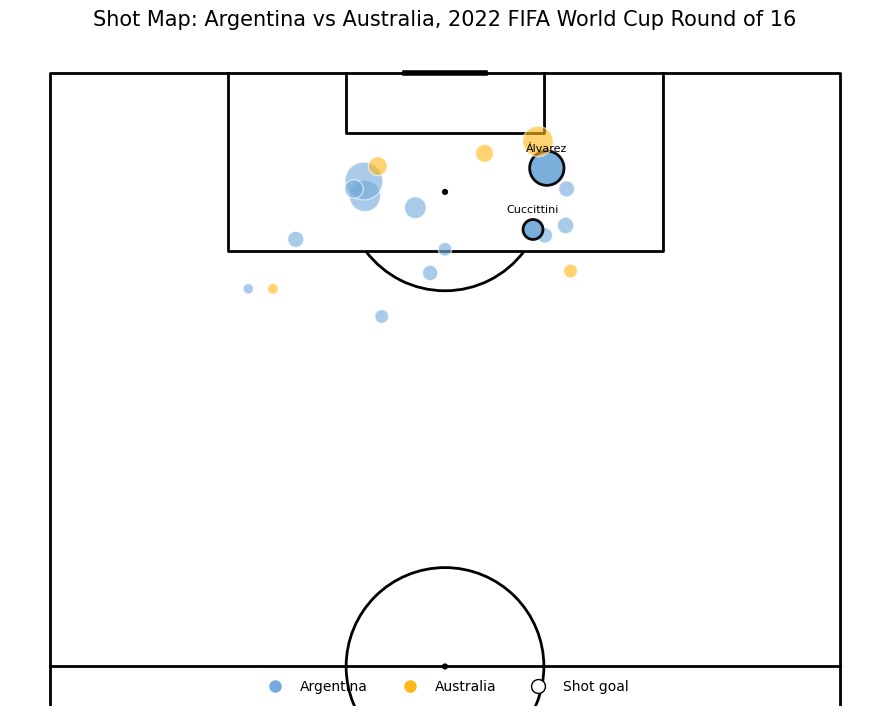

In [72]:
shots = add_xy_columns(events[events['type'] == 'Shot'].copy())
shot_summary = shots.groupby('team').agg(
    Shots=('id', 'count'),
    xG=('shot_statsbomb_xg', 'sum'),
    Shot_Goals=('shot_outcome', lambda s: s.eq('Goal').sum()),
).reindex(TEAMS).fillna(0)
display(shot_summary.style.format({'xG': '{:.2f}'}))

pitch = VerticalPitch(half=True, pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(9, 9))

for team, team_shots in shots.groupby('team'):
    goals = team_shots['shot_outcome'].eq('Goal')
    pitch.scatter(
        team_shots.loc[~goals, 'x'], team_shots.loc[~goals, 'y'],
        s=team_shots.loc[~goals, 'shot_statsbomb_xg'].fillna(0.01) * 1900 + 35,
        c=TEAM_COLORS.get(team, 'grey'), alpha=0.62, edgecolors='white', linewidth=0.9, ax=ax, label=team
    )
    pitch.scatter(
        team_shots.loc[goals, 'x'], team_shots.loc[goals, 'y'],
        s=team_shots.loc[goals, 'shot_statsbomb_xg'].fillna(0.01) * 1900 + 80,
        c=TEAM_COLORS.get(team, 'grey'), alpha=0.95, edgecolors='black', linewidth=2.0, ax=ax
    )

for _, row in shots[shots['shot_outcome'].eq('Goal')].iterrows():
    ax.text(row['y'], row['x'] + 1.5, row['player'].split()[-1], ha='center', va='bottom', fontsize=8)

legend_items = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TEAM_COLORS[HOME_TEAM], label=HOME_TEAM, markersize=10),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TEAM_COLORS[AWAY_TEAM], label=AWAY_TEAM, markersize=10),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', markeredgecolor='black', label='Shot goal', markersize=10),
]
ax.legend(handles=legend_items, loc='lower center', ncol=3, frameon=False)
ax.set_title(f'Shot Map: {MATCH_LABEL}, {COMPETITION_LABEL}')
plt.show()


**Interpretation:** Argentina produced 14 shots worth 1.48 xG and two shot goals, while Australia produced 5 shots worth 0.43 xG and no shot goals in the event feed. The final score is closer than the shot profile because Australia’s goal came through the own-goal/deflection sequence rather than a recorded Australian shot goal.


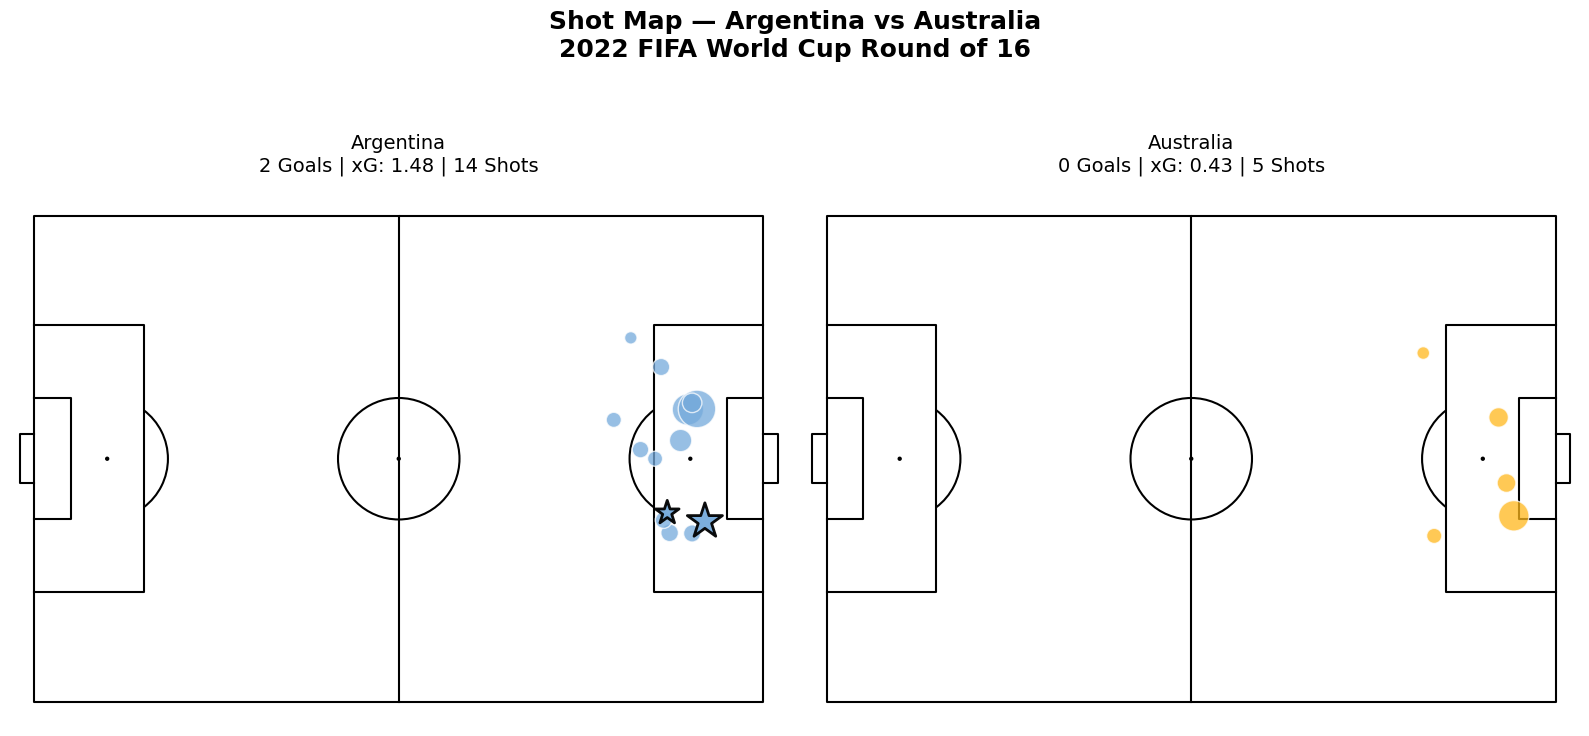

In [85]:
# ==================== SHOT SUMMARY ====================
shots = add_xy_columns(events[events['type'] == 'Shot'].copy())

shot_summary = shots.groupby('team').agg(
    Goals=('shot_outcome', lambda s: (s == 'Goal').sum()),
    xG=('shot_statsbomb_xg', 'sum'),
    Shots=('id', 'count')
).reindex(TEAMS).fillna(0)

# ==================== DUAL SHOT MAP (Lecture Style) ====================
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

for idx, team in enumerate(TEAMS):
    ax = axs[idx]
    team_shots = shots[shots['team'] == team].copy()
    color = TEAM_COLORS[team]
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black',
                  goal_type='box', linewidth=1.5)
    pitch.draw(ax=ax)
    
    #goals = team_shots['shot_outcome'].eq('Goal')
    # Inside the loop, replace the goals line with this:
    goals = (team_shots['shot_outcome'].eq('Goal')) | \
        (team_shots['shot_outcome'].eq('Own Goal')) | \
        (team_shots['type'] == 'Own Goal')   # extra safety

# Also increase visibility for Australia's goal
    
    # Normal shots
    pitch.scatter(
        team_shots.loc[~goals, 'x'], team_shots.loc[~goals, 'y'],
        s=team_shots.loc[~goals, 'shot_statsbomb_xg'].fillna(0.01) * 1800 + 60,
        c=color, alpha=0.75, edgecolors='white', linewidth=1, ax=ax
    )
    
    # Goals with star
    pitch.scatter(
        team_shots.loc[goals, 'x'], team_shots.loc[goals, 'y'],
        s=team_shots.loc[goals, 'shot_statsbomb_xg'].fillna(0.01) * 1800 + 200,
        c=color, alpha=0.95, edgecolors='black', linewidth=2, ax=ax,
        marker='*', zorder=5
    )
    
    # Title for each subplot
    ax.set_title(f"{team}\n{int(shot_summary.loc[team, 'Goals'])} Goals | "
                 f"xG: {shot_summary.loc[team, 'xG']:.2f} | "
                 f"{int(shot_summary.loc[team, 'Shots'])} Shots", 
                 fontsize=14, pad=15)

# Overall title
fig.suptitle(f'Shot Map — {MATCH_LABEL}\n{COMPETITION_LABEL}', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

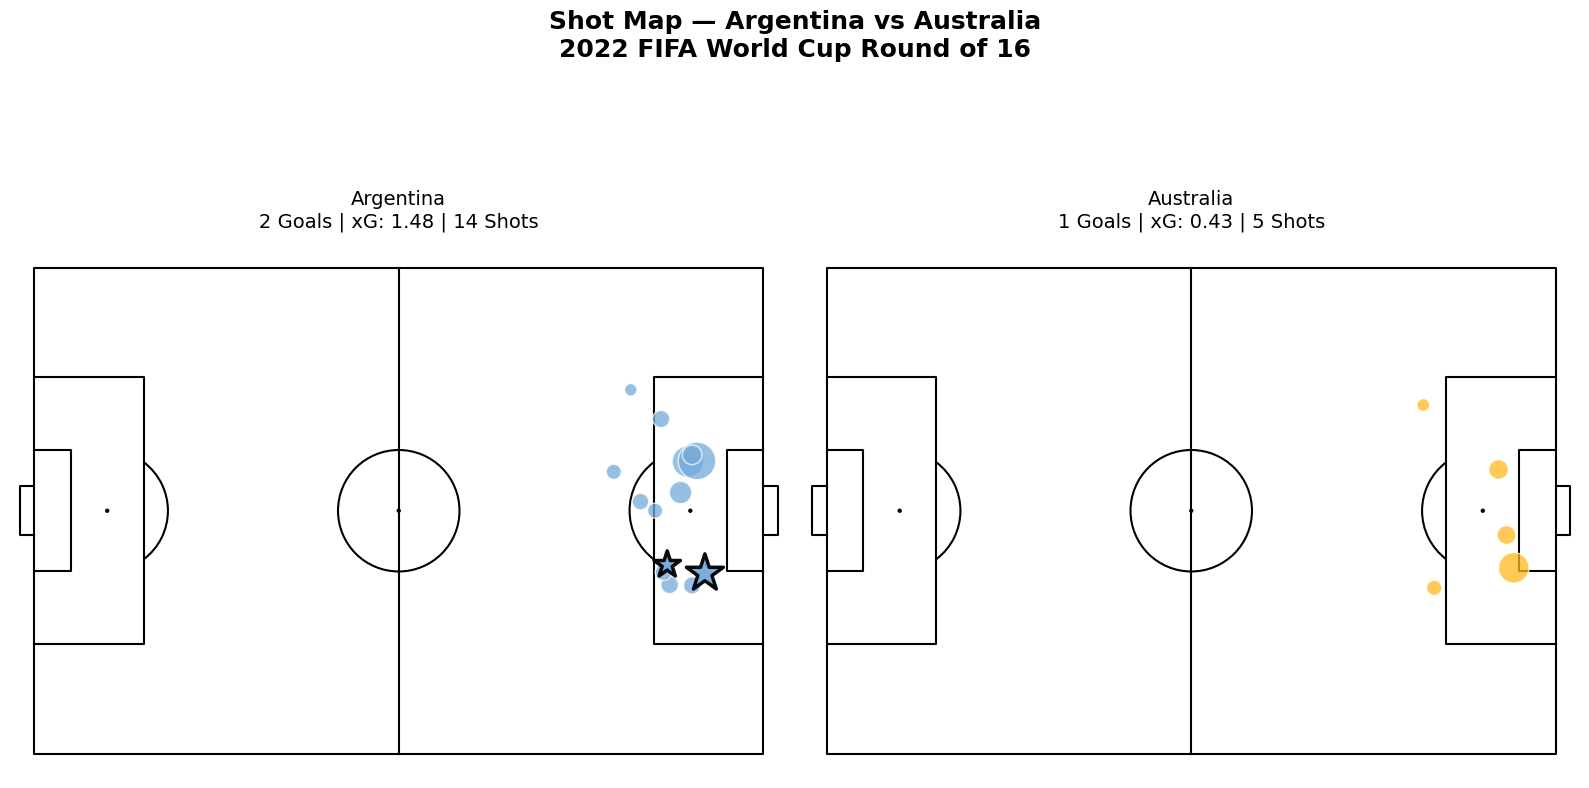

In [86]:
# ==================== SHOT SUMMARY ====================
shots = add_xy_columns(events[events['type'] == 'Shot'].copy())

shot_summary = shots.groupby('team').agg(
    Goals=('shot_outcome', lambda s: (s == 'Goal').sum()),
    xG=('shot_statsbomb_xg', 'sum'),
    Shots=('id', 'count')
).reindex(TEAMS).fillna(0)

# Manually add Australia's goal (since it's probably an own goal)
shot_summary.loc['Australia', 'Goals'] = 1

# ==================== DUAL SHOT MAP (Lecture Style) ====================
fig, axs = plt.subplots(1, 2, figsize=(16, 9))

for idx, team in enumerate(TEAMS):
    ax = axs[idx]
    team_shots = shots[shots['team'] == team].copy()
    color = TEAM_COLORS[team]
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black',
                  goal_type='box', linewidth=1.5)
    pitch.draw(ax=ax)
    
    # Better goal detection
    is_goal = team_shots['shot_outcome'].isin(['Goal', 'Own Goal']) | \
              (team_shots['type'] == 'Own Goal')
    
    # Normal shots (non-goals)
    pitch.scatter(
        team_shots.loc[~is_goal, 'x'], 
        team_shots.loc[~is_goal, 'y'],
        s=team_shots.loc[~is_goal, 'shot_statsbomb_xg'].fillna(0.01) * 1800 + 60,
        c=color, alpha=0.75, edgecolors='white', linewidth=1, ax=ax
    )
    
    # Goals as big stars
    if is_goal.any():
        pitch.scatter(
            team_shots.loc[is_goal, 'x'], 
            team_shots.loc[is_goal, 'y'],
            s=team_shots.loc[is_goal, 'shot_statsbomb_xg'].fillna(0.1) * 1800 + 280,
            c=color, alpha=0.95, edgecolors='black', linewidth=2.5,
            marker='*', zorder=5, ax=ax
        )

    # Title
    ax.set_title(f"{team}\n"
                 f"{int(shot_summary.loc[team, 'Goals'])} Goals | "
                 f"xG: {shot_summary.loc[team, 'xG']:.2f} | "
                 f"{int(shot_summary.loc[team, 'Shots'])} Shots", 
                 fontsize=14, pad=12)

fig.suptitle(f'Shot Map — {MATCH_LABEL}\n{COMPETITION_LABEL}', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## 2. xG Timeline

**How to read this chart:** the line rises after each shot by that shot’s xG value. Steep jumps show big chances, goal markers show when shots became goals, and flat sections show periods without shots.


,minute,second,team,player,shot_statsbomb_xg
4061,34,35,Argentina,Lionel Andrés Messi Cuccittini,0.066638
4063,56,41,Argentina,Julián Álvarez,0.280607


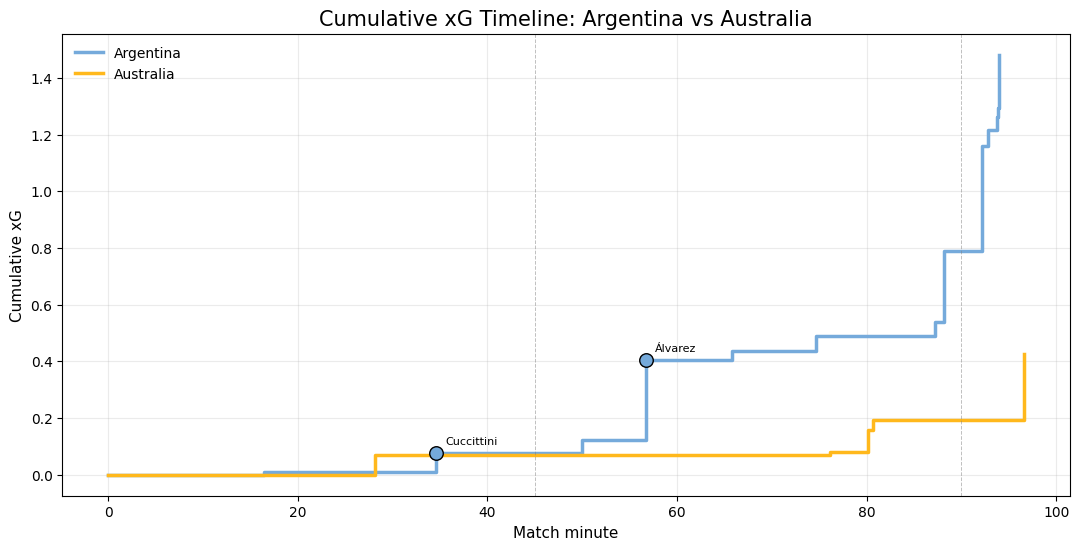

In [73]:
shots_timeline = shots.sort_values(['minute', 'second']).copy()
shots_timeline['match_minute'] = shots_timeline['minute'] + shots_timeline['second'] / 60

goals_table = shots_timeline[shots_timeline['shot_outcome'].eq('Goal')][['minute', 'second', 'team', 'player', 'shot_statsbomb_xg']]
display(goals_table)

fig, ax = plt.subplots(figsize=(13, 6))

for team in TEAMS:
    team_shots = shots_timeline[shots_timeline['team'] == team].copy()
    team_shots['cum_xg'] = team_shots['shot_statsbomb_xg'].fillna(0).cumsum()
    x_values = np.r_[0, team_shots['match_minute'].to_numpy()]
    y_values = np.r_[0, team_shots['cum_xg'].to_numpy()]
    ax.step(x_values, y_values, where='post', color=TEAM_COLORS[team], linewidth=2.5, label=team)

    goals = team_shots[team_shots['shot_outcome'].eq('Goal')]
    for _, row in goals.iterrows():
        goal_y = team_shots.loc[team_shots.index <= row.name, 'shot_statsbomb_xg'].fillna(0).sum()
        ax.scatter(row['match_minute'], goal_y, s=95, color=TEAM_COLORS[team], edgecolor='black', zorder=5)
        ax.text(row['match_minute'] + 1, goal_y + 0.03, row['player'].split()[-1], fontsize=8)

for minute in [45, 90]:
    ax.axvline(minute, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)

ax.set_title(f'Cumulative xG Timeline: {MATCH_LABEL}')
ax.set_xlabel('Match minute')
ax.set_ylabel('Cumulative xG')
ax.legend(frameon=False)
ax.grid(alpha=0.25)
plt.show()


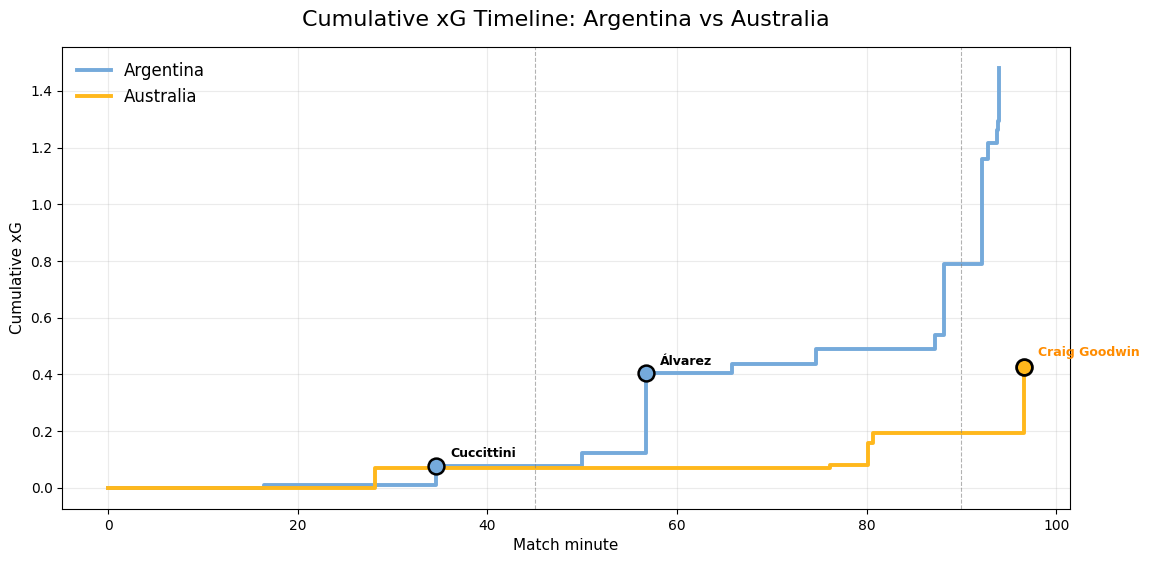

In [111]:
shots_timeline = shots.sort_values(['minute', 'second']).copy()
shots_timeline['match_minute'] = shots_timeline['minute'] + shots_timeline['second'] / 60.0

# Robust goal detection
shots_timeline['is_goal'] = shots_timeline['shot_outcome'].isin(['Goal', 'Own Goal'])

fig, ax = plt.subplots(figsize=(13, 6))

for team in TEAMS:
    team_shots = shots_timeline[shots_timeline['team'] == team].copy()
    team_shots['cum_xg'] = team_shots['shot_statsbomb_xg'].fillna(0).cumsum()
    
    x_values = np.r_[0, team_shots['match_minute'].to_numpy()]
    y_values = np.r_[0, team_shots['cum_xg'].to_numpy()]
    
    ax.step(x_values, y_values, where='post', color=TEAM_COLORS[team], 
            linewidth=2.8, label=team)

    # Plot detected goals
    goals = team_shots[team_shots['is_goal']]
    for _, row in goals.iterrows():
        goal_y = team_shots.loc[team_shots.index <= row.name, 'cum_xg'].iloc[-1]
        ax.scatter(row['match_minute'], goal_y, s=130, color=TEAM_COLORS[team], 
                   edgecolor='black', linewidth=1.8, zorder=6)
        ax.text(row['match_minute'] + 1.5, goal_y + 0.03, 
                row['player'].split()[-1], fontsize=9, fontweight='bold')

# === MANUAL FIX FOR AUSTRALIA'S GOAL (if not detected) ===
aus_shots = shots_timeline[shots_timeline['team'] == 'Australia'].copy()
if not aus_shots.empty:
    aus_shots['cum_xg'] = aus_shots['shot_statsbomb_xg'].fillna(0).cumsum()
    last_xg = aus_shots['cum_xg'].iloc[-1]
    last_minute = aus_shots['match_minute'].iloc[-1]
    
    ax.scatter(last_minute, last_xg, s=130, color=TEAM_COLORS['Australia'], 
               edgecolor='black', linewidth=2, zorder=6)
    ax.text(last_minute + 1.5, last_xg + 0.04, "Craig Goodwin", 
            fontsize=9, fontweight='bold', color='darkorange')

# Half time and full time lines
for minute in [45, 90]:
    ax.axvline(minute, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title(f'Cumulative xG Timeline: {MATCH_LABEL}', fontsize=16, pad=15)
ax.set_xlabel('Match minute')
ax.set_ylabel('Cumulative xG')
ax.legend(frameon=False, fontsize=12)
ax.grid(alpha=0.25)
plt.show()

**Interpretation:** Argentina’s xG line grows more often and finishes at 1.48, while Australia’s line finishes at 0.43. Messi’s 35th-minute goal and Alvarez’s 57th-minute goal are the decisive shot outcomes, and Australia’s late score pressure is not represented as a shot goal in the event feed.


## 3. Passing Networks

**How to read these charts:** node position is the player’s average completed-pass location, node size reflects completed-pass volume, and thicker edges show more frequent passing combinations. The two networks use the same visual rules so team structure can be compared.


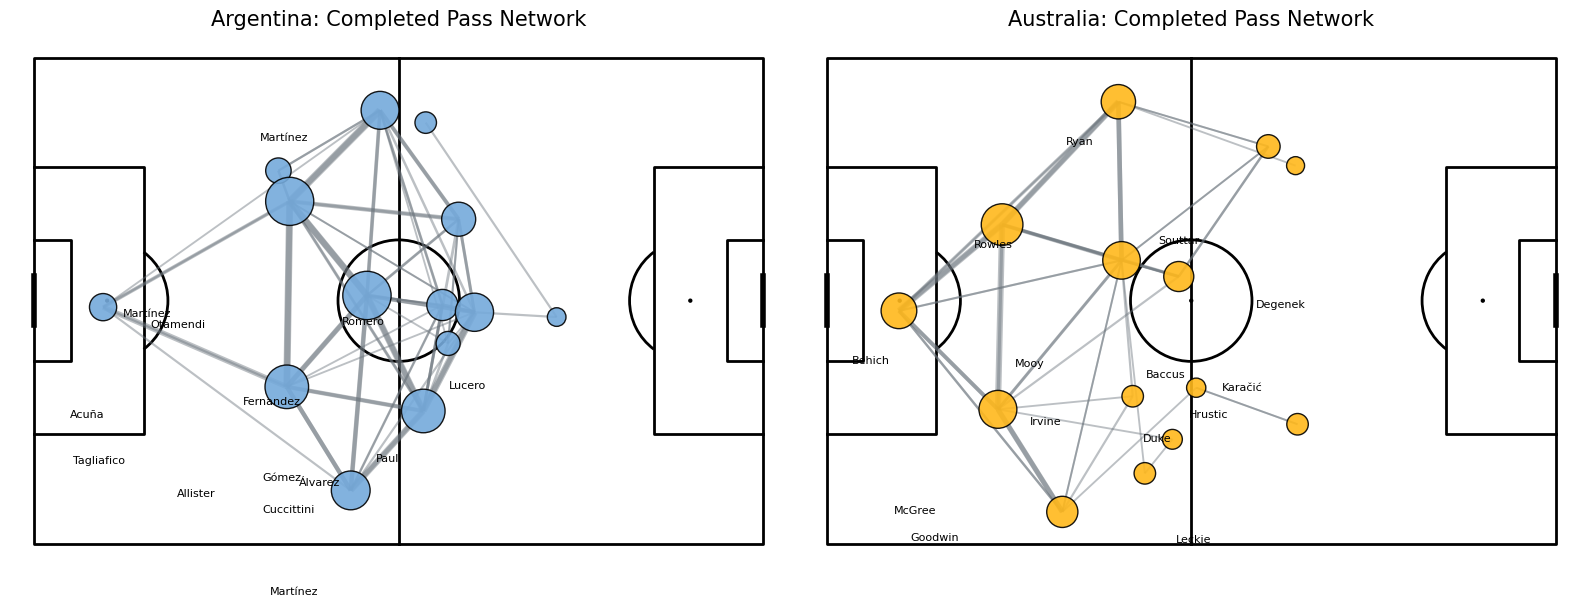

,Completed Passes,Players Shown,Links Shown
Argentina,646,14,69
Australia,384,14,45


In [74]:
def plot_passing_network(team, ax, min_passes=3):
    passes = events[(events['type'] == 'Pass') & (events['team'] == team)].copy()
    passes = passes[passes['pass_outcome'].isna()].copy()
    passes = add_xy_columns(passes, end_col='pass_end_location')
    passes = passes.dropna(subset=['player', 'pass_recipient', 'x', 'y'])

    player_counts = passes['player'].value_counts()
    main_players = player_counts.head(14).index
    network_passes = passes[passes['player'].isin(main_players) & passes['pass_recipient'].isin(main_players)]

    avg_locations = network_passes.groupby('player').agg(x=('x', 'mean'), y=('y', 'mean'), touches=('player', 'size'))
    combinations = network_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='passes')
    combinations = combinations[combinations['passes'] >= min_passes]

    for _, row in combinations.iterrows():
        if row['player'] in avg_locations.index and row['pass_recipient'] in avg_locations.index:
            start = avg_locations.loc[row['player']]
            end = avg_locations.loc[row['pass_recipient']]
            pitch.lines(start.x, start.y, end.x, end.y, lw=0.7 + row['passes'] * 0.22,
                        color='#6C757D', alpha=0.45, ax=ax, zorder=1)

    if not avg_locations.empty:
        pitch.scatter(avg_locations['x'], avg_locations['y'],
                      s=avg_locations['touches'] * 12 + 120, color=TEAM_COLORS[team],
                      edgecolors='black', linewidth=1, alpha=0.9, ax=ax, zorder=2)
        for player, row in avg_locations.iterrows():
            ax.text(row.y, row.x + 1.8, player.split()[-1], ha='center', va='center', fontsize=8, zorder=3)
    ax.set_title(f'{team}: Completed Pass Network')
    return pd.Series({'Completed Passes': len(passes), 'Players Shown': len(avg_locations), 'Links Shown': len(combinations)})

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axs = pitch.draw(ncols=2, figsize=(16, 7))
axs = np.ravel(axs)
network_summary = []
for ax, team in zip(axs, TEAMS):
    network_summary.append(plot_passing_network(team, ax).rename(team))
plt.show()

display(pd.DataFrame(network_summary))


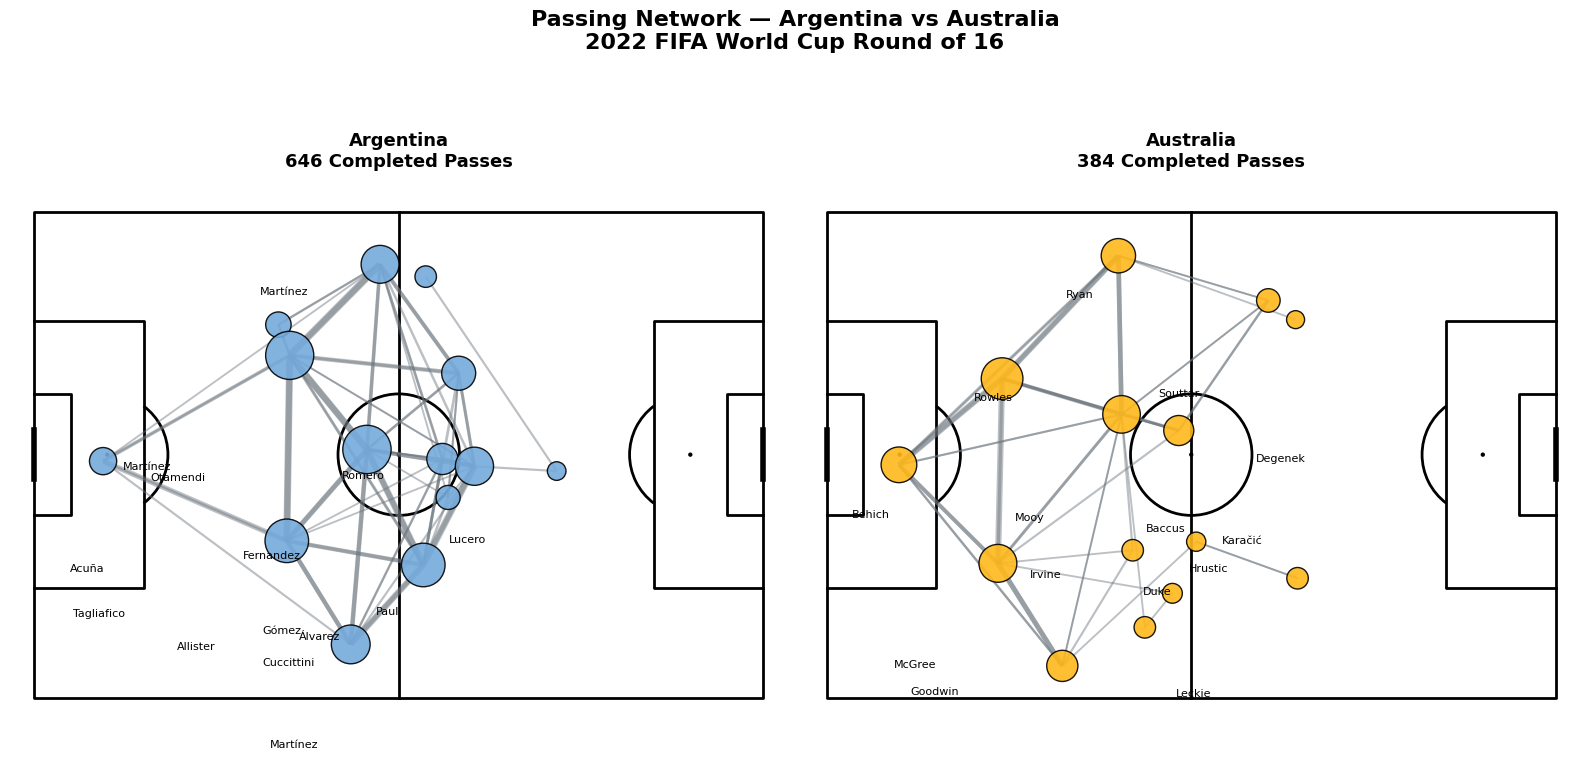

,Completed Passes,Players Shown,Links Shown
Team,,,
Argentina,646,14,69
Australia,384,14,45


In [91]:
def plot_passing_network(team, ax, min_passes=3):
    passes = events[(events['type'] == 'Pass') & (events['team'] == team)].copy()
    passes = passes[passes['pass_outcome'].isna()].copy()  # Completed passes only
    passes = add_xy_columns(passes, end_col='pass_end_location')
    passes = passes.dropna(subset=['player', 'pass_recipient', 'x', 'y'])

    completed_passes = len(passes)
    
    player_counts = passes['player'].value_counts()
    main_players = player_counts.head(14).index
    network_passes = passes[passes['player'].isin(main_players) & 
                           passes['pass_recipient'].isin(main_players)]

    avg_locations = network_passes.groupby('player').agg(
        x=('x', 'mean'), 
        y=('y', 'mean'), 
        touches=('player', 'size')
    )
    
    combinations = network_passes.groupby(['player', 'pass_recipient']).size().reset_index(name='passes')
    combinations = combinations[combinations['passes'] >= min_passes]

    # Draw pass lines
    for _, row in combinations.iterrows():
        if row['player'] in avg_locations.index and row['pass_recipient'] in avg_locations.index:
            start = avg_locations.loc[row['player']]
            end = avg_locations.loc[row['pass_recipient']]
            pitch.lines(start.x, start.y, end.x, end.y, 
                        lw=0.7 + row['passes'] * 0.22,
                        color='#6C757D', alpha=0.45, ax=ax, zorder=1)

    # Draw player nodes
    if not avg_locations.empty:
        pitch.scatter(avg_locations['x'], avg_locations['y'],
                      s=avg_locations['touches'] * 12 + 120, 
                      color=TEAM_COLORS[team], edgecolors='black', 
                      linewidth=1, alpha=0.9, ax=ax, zorder=2)
        
        for player, row in avg_locations.iterrows():
            ax.text(row.y, row.x + 1.8, player.split()[-1], 
                    ha='center', va='center', fontsize=8, zorder=3)

    # Title with completed passes count
    ax.set_title(f'{team}\n{completed_passes} Completed Passes', 
                 fontsize=13, pad=15, fontweight='bold')
    
    return pd.Series({
        'Team': team,
        'Completed Passes': completed_passes,
        'Players Shown': len(avg_locations),
        'Links Shown': len(combinations)
    })


# ==================== PLOT ====================
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axs = pitch.draw(ncols=2, figsize=(16, 8))
axs = np.ravel(axs)

network_summary = []
for ax, team in zip(axs, TEAMS):
    summary = plot_passing_network(team, ax)
    network_summary.append(summary)

plt.suptitle(f'Passing Network — {MATCH_LABEL}\n{COMPETITION_LABEL}', 
             fontsize=16, fontweight='bold', y=1.02)

plt.show()

# Summary Table
display(pd.DataFrame(network_summary).set_index('Team'))

**Interpretation:** Argentina’s network is larger and more connected, built from 646 completed passes. Australia completed 384 passes and its network is more defender-heavy, matching a team that spent longer phases protecting shape and building from deeper areas.


## 4. Multi-Player Heatmaps

**How to read these charts:** each panel shows one player’s event-density footprint. Hotter areas mean more involvement there, not necessarily better performance. The same bins and smoothing are used across all eight players.


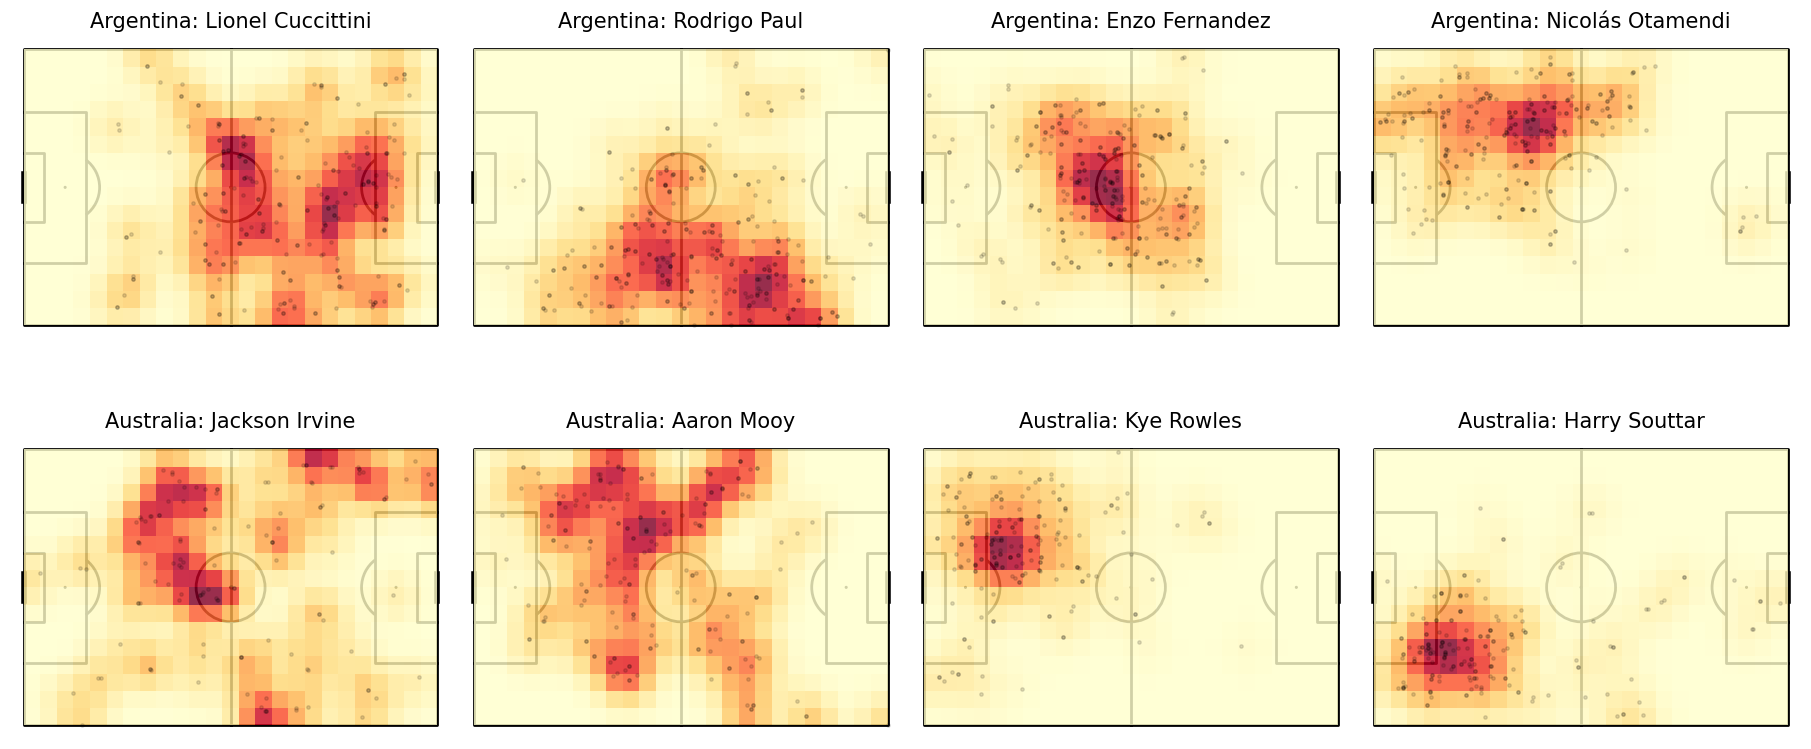

,Team,Player,Located Events
0,Argentina,Lionel Andrés Messi Cuccittini,235
1,Argentina,Rodrigo Javier De Paul,298
2,Argentina,Enzo Fernandez,311
3,Argentina,Nicolás Hernán Otamendi,288
4,Australia,Jackson Irvine,127
5,Australia,Aaron Mooy,185
6,Australia,Kye Rowles,197
7,Australia,Harry Souttar,194


In [75]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axs = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)
heatmap_summary = []

for row_idx, team in enumerate(TEAMS):
    for col_idx, player in enumerate(HEATMAP_PLAYERS[team]):
        ax = axs[row_idx, col_idx]
        pitch.draw(ax=ax)
        pe = add_xy_columns(player_events(player)).dropna(subset=['x', 'y'])
        heatmap_summary.append({'Team': team, 'Player': player_label(player), 'Located Events': len(pe)})
        if pe.empty:
            ax.text(60, 40, 'No events', ha='center', va='center')
        else:
            bin_stat = pitch.bin_statistic(pe['x'], pe['y'], statistic='count', bins=(25, 16))
            bin_stat['statistic'] = gaussian_filter(bin_stat['statistic'], sigma=1)
            pitch.heatmap(bin_stat, ax=ax, cmap='YlOrRd', edgecolors='none', alpha=0.82)
            pitch.scatter(pe['x'], pe['y'], s=6, color='black', alpha=0.13, ax=ax)
        ax.set_title(f'{team}: {display_player_name(player)}')

plt.show()
display(pd.DataFrame(heatmap_summary))


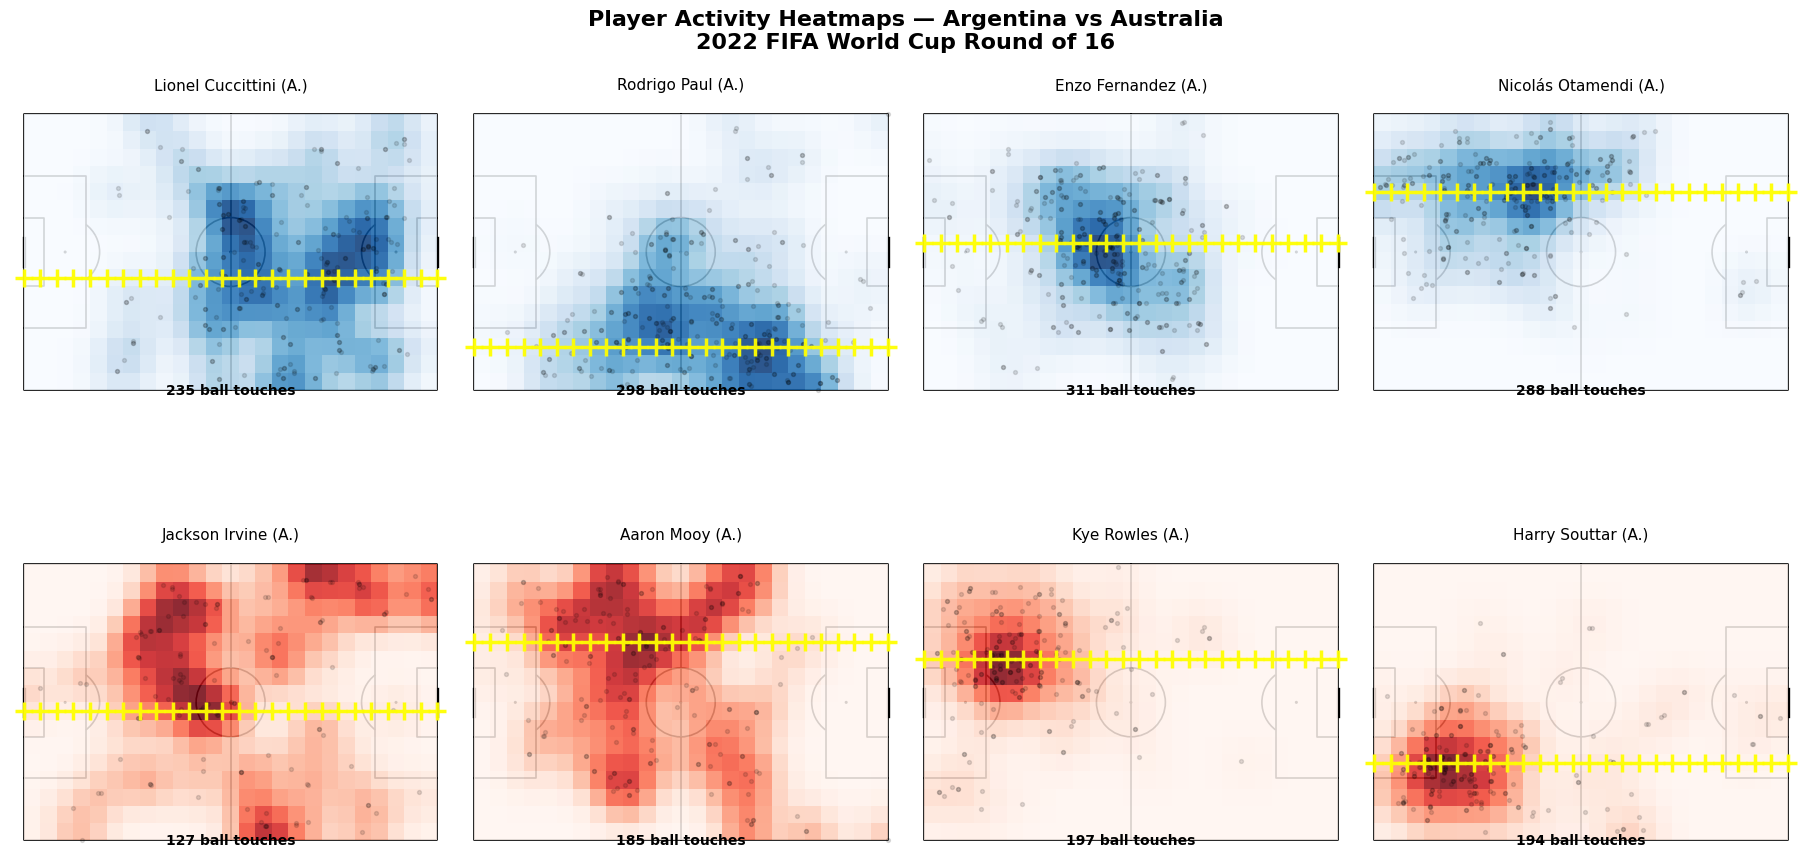

,Team,Player,Ball Touches
0,Argentina,Lionel Cuccittini,235
1,Argentina,Rodrigo Paul,298
2,Argentina,Enzo Fernandez,311
3,Argentina,Nicolás Otamendi,288
4,Australia,Jackson Irvine,127
5,Australia,Aaron Mooy,185
6,Australia,Kye Rowles,197
7,Australia,Harry Souttar,194


In [98]:
pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black', linewidth=1.2)

fig, axs = plt.subplots(2, 4, figsize=(18, 9), constrained_layout=True)
heatmap_summary = []

for row_idx, team in enumerate(TEAMS):
    cmap = 'Blues' if team == HOME_TEAM else 'Reds'
    
    for col_idx, player in enumerate(HEATMAP_PLAYERS[team]):
        ax = axs[row_idx, col_idx]
        pitch.draw(ax=ax)
        
        pe = add_xy_columns(player_events(player)).dropna(subset=['x', 'y'])
        total_touches = len(pe)
        
        if pe.empty:
            ax.text(60, 40, 'No events', ha='center', va='center', fontsize=12)
            continue
            
        # Heatmap
        bin_stat = pitch.bin_statistic(pe['x'], pe['y'], statistic='count', bins=(25, 16))
        smoothed = gaussian_filter(bin_stat['statistic'], sigma=1.2)
        bin_stat['statistic'] = smoothed
        
        pitch.heatmap(bin_stat, ax=ax, cmap=cmap, edgecolors='none', alpha=0.85)
        pitch.scatter(pe['x'], pe['y'], s=8, color='black', alpha=0.12, ax=ax)
        
        # === SAFE PEAK MARKER ===
        if smoothed.max() > 0:
            y_idx, x_idx = np.unravel_index(smoothed.argmax(), smoothed.shape)
            
            # Safe grid center calculation - clamp indices to valid range
            x_grid = bin_stat['x_grid']
            y_grid = bin_stat['y_grid']
            
            # Clamp x_idx to ensure we don't go out of bounds
            x_idx_safe = min(x_idx, len(x_grid) - 2)
            y_idx_safe = min(y_idx, len(y_grid) - 2)
            
            peak_x = (x_grid[x_idx_safe] + x_grid[x_idx_safe + 1]) / 2
            peak_y = (y_grid[y_idx_safe] + y_grid[y_idx_safe + 1]) / 2
            
            ax.scatter(peak_x, peak_y, s=180, color='yellow', edgecolor='black', 
                      linewidth=2.5, zorder=5, marker='+', alpha=0.95)

        # Title
        short_name = display_player_name(player)
        ax.set_title(f'{short_name} ({team[0]}.)', fontsize=11, pad=8)
        ax.text(60, 78, f'{total_touches} ball touches', ha='center', va='top', 
                fontsize=10, fontweight='bold')

        heatmap_summary.append({
            'Team': team,
            'Player': short_name,
            'Ball Touches': total_touches
        })

fig.suptitle('Player Activity Heatmaps — Argentina vs Australia\n'
             '2022 FIFA World Cup Round of 16', fontsize=16, fontweight='bold', y=1.02)

plt.show()

display(pd.DataFrame(heatmap_summary))

**Interpretation:** Argentina’s selected heatmaps show a spread from Messi’s advanced/right-sided influence to De Paul and Enzo Fernandez connecting midfield, with Otamendi anchoring deeper circulation. Australia’s selected heatmaps are more defensive and build-up oriented, especially through Rowles, Souttar, Mooy, and Irvine.


## 5. Radar Comparisons

**How to read these charts:** each radar is normalized within its comparison group. The shape shows relative profile, not an absolute rating. The left radar compares one key player from each team, while the right radar compares team-level event profiles.


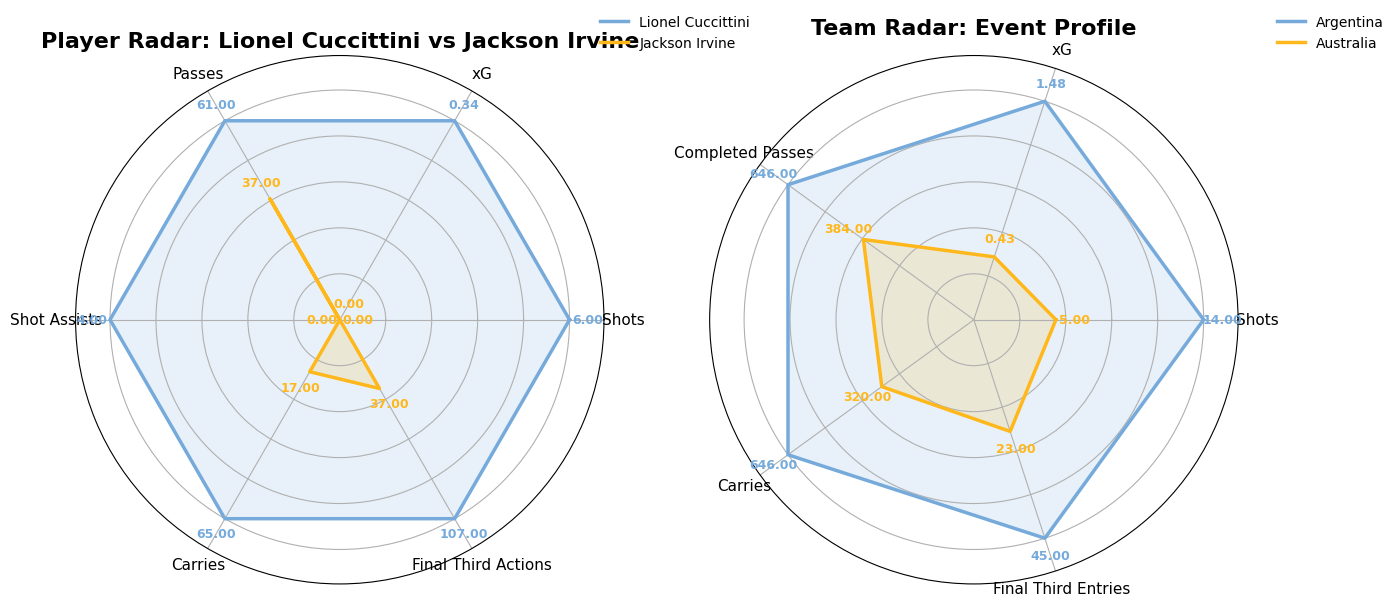

,Shots,xG,Passes,Shot Assists,Carries,Final Third Actions
Name,,,,,,
Lionel Andrés Messi Cuccittini,6,0.342741,61,4,65,107
Jackson Irvine,0,0.000000,37,0,17,37


,Shots,xG,Completed Passes,Carries,Final Third Entries
Name,,,,,
Argentina,14,1.481579,646,646,45
Australia,5,0.426118,384,320,23


In [99]:
def player_metric_table(players):
    metric_rows = []
    resolved_players = [player_label(player) for player in players]
    for player in resolved_players:
        pe = events[events['player'] == player].copy()
        player_shots = pe[pe['type'] == 'Shot']
        player_passes = pe[pe['type'] == 'Pass']
        player_carries = pe[pe['type'] == 'Carry']
        metric_rows.append({
            'Name': player,
            'Shots': len(player_shots),
            'xG': player_shots['shot_statsbomb_xg'].fillna(0).sum(),
            'Passes': len(player_passes),
            'Shot Assists': safe_bool(player_passes.get('pass_shot_assist', pd.Series(index=player_passes.index))).sum(),
            'Carries': len(player_carries),
            'Final Third Actions': add_xy_columns(pe).query('x >= 80').shape[0],
        })
    return pd.DataFrame(metric_rows).set_index('Name')


'''def draw_radar(ax, raw, title, colors_by_name):
    radar_norm = normalize_metric_values(raw)
    labels = radar_norm.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]
    for name in radar_norm.index:
        values = radar_norm.loc[name].tolist()
        values += values[:1]
        color = colors_by_name.get(name, '#6C757D')
        label = display_player_name(name) if name not in TEAMS else name
        ax.plot(angles, values, color=color, linewidth=2.5, label=label)
        ax.fill(angles, values, color=color, alpha=0.16)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)
    ax.set_yticklabels([])
    ax.set_ylim(0, 1.05)
    ax.set_title(title)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False)
'''
def draw_radar(ax, raw, title, colors_by_name):
    radar_norm = normalize_metric_values(raw)

    labels = radar_norm.columns.tolist()
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    for name in radar_norm.index:

        # normalized values for radar shape
        values = radar_norm.loc[name].tolist()
        values += values[:1]

        # original values for text labels
        raw_values = raw.loc[name].tolist()
        raw_values += raw_values[:1]

        color = colors_by_name.get(name, '#6C757D')
        label = display_player_name(name) if name not in TEAMS else name

        # radar line
        ax.plot(angles, values, color=color, linewidth=2.5, label=label)
        ax.fill(angles, values, color=color, alpha=0.16)

        # add numeric labels
        for angle, value, raw_val in zip(angles[:-1], values[:-1], raw_values[:-1]):

            ax.text(
                angle,
                value + 0.08,  # slightly outside polygon
                f'{raw_val:.2f}' if isinstance(raw_val, float) else str(raw_val),
                color=color,
                fontsize=9,
                ha='center',
                va='center',
                fontweight='bold'
            )

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=11)

    ax.set_yticklabels([])
    ax.set_ylim(0, 1.15)

    ax.set_title(title, fontsize=16, fontweight='bold')

    ax.legend(
        loc='upper right',
        bbox_to_anchor=(1.3, 1.1),
        frameon=False
    )
radar_raw = player_metric_table(RADAR_PLAYERS)
team_radar_raw = scorecard[['Shots', 'xG', 'Completed Passes', 'Carries', 'Final Third Entries']].copy()
team_radar_raw.index.name = 'Name'

fig, axs = plt.subplots(1, 2, figsize=(15, 7), subplot_kw={'polar': True})
player_colors = {
    player_label(RADAR_PLAYERS[0]): TEAM_COLORS[HOME_TEAM],
    player_label(RADAR_PLAYERS[1]): TEAM_COLORS[AWAY_TEAM],
}
draw_radar(axs[0], radar_raw, f'Player Radar: {display_player_name(RADAR_PLAYERS[0])} vs {display_player_name(RADAR_PLAYERS[1])}', player_colors)
draw_radar(axs[1], team_radar_raw, 'Team Radar: Event Profile', TEAM_COLORS)
plt.show()

display(radar_raw)
display(team_radar_raw)


**Interpretation:** Messi’s profile is more attacking and final-third weighted, while Irvine’s profile reflects Australia’s midfield work. At team level, Argentina leads the radar categories for shots, xG, completed passing, carries, and final-third entries.


## 6. Dangerous Passes

**How to read this chart:** arrows show completed final-third entries, official shot/goal assists, and high-xT passes. This captures both direct chance creation and passes that move the ball into much more dangerous areas.


,Dangerous_Passes,Shot_Assists,Goal_Assists,Final_Third_Entries,High_xT_Passes
team,,,,,
Argentina,74,9,1,45,34
Australia,39,3,0,23,21


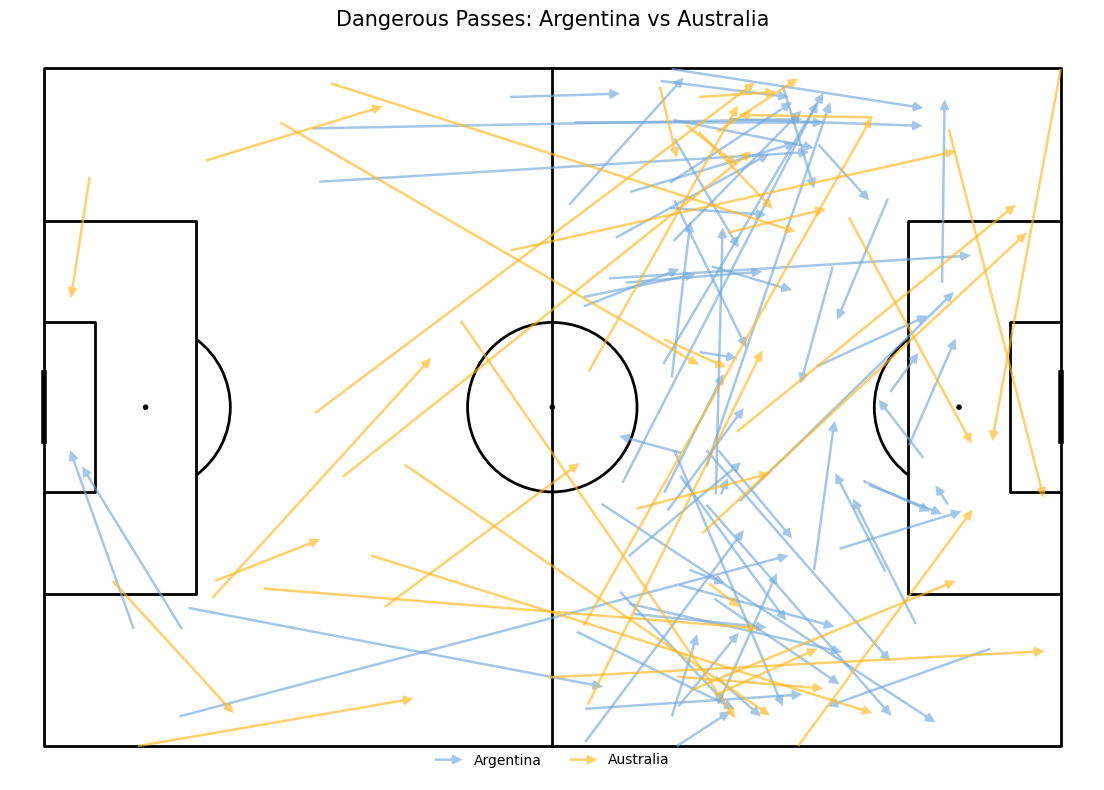

,minute,team,player,pass_recipient,xT_gain
1144,88,Australia,Fran Karačić,Harry Souttar,0.258076
504,34,Argentina,Alexis Mac Allister,Nicolás Hernán Otamendi,0.230775
1128,87,Argentina,Rodrigo Javier De Paul,Lautaro Javier Martínez,0.227563
439,28,Australia,Riley McGree,Harry Souttar,0.215779
881,62,Australia,Craig Goodwin,Mathew Leckie,0.183177
651,46,Argentina,Cristian Gabriel Romero,Damián Emiliano Martínez,0.144074
1208,96,Australia,Craig Goodwin,Garang Kuol,0.142527
627,44,Australia,Harry Souttar,Miloš Degenek,0.137969
153,9,Argentina,Alejandro Darío Gómez,Lionel Andrés Messi Cuccittini,0.069260
884,62,Australia,Aaron Mooy,Craig Goodwin,0.067210


In [77]:
xt_grid = load_xt_grid()
all_passes = add_xy_columns(events[events['type'] == 'Pass'].copy(), end_col='pass_end_location')
all_passes = all_passes.dropna(subset=['x', 'y', 'end_x', 'end_y'])
all_passes['start_xT'] = all_passes.apply(lambda r: xt_value(r.x, r.y, xt_grid), axis=1)
all_passes['end_xT'] = all_passes.apply(lambda r: xt_value(r.end_x, r.end_y, xt_grid), axis=1)
all_passes['xT_gain'] = all_passes['end_xT'] - all_passes['start_xT']
all_passes['completed'] = all_passes['pass_outcome'].isna()
all_passes['shot_assist'] = safe_bool(all_passes.get('pass_shot_assist', pd.Series(index=all_passes.index)))
all_passes['goal_assist'] = safe_bool(all_passes.get('pass_goal_assist', pd.Series(index=all_passes.index)))
all_passes['final_third_entry'] = all_passes['completed'] & (all_passes['x'] < 80) & (all_passes['end_x'] >= 80)
all_passes['high_xt'] = all_passes['completed'] & (all_passes['xT_gain'] >= all_passes['xT_gain'].quantile(0.92))

dangerous = all_passes[all_passes['shot_assist'] | all_passes['goal_assist'] | all_passes['final_third_entry'] | all_passes['high_xt']].copy()
danger_summary = all_passes.groupby('team').agg(
    Dangerous_Passes=('high_xt', lambda s: int(dangerous.index.isin(s.index).sum())),
    Shot_Assists=('shot_assist', 'sum'),
    Goal_Assists=('goal_assist', 'sum'),
    Final_Third_Entries=('final_third_entry', 'sum'),
    High_xT_Passes=('high_xt', 'sum'),
).reindex(TEAMS).fillna(0).astype(int)
display(danger_summary)

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(13, 8))

for team, df_team in dangerous.groupby('team'):
    pitch.arrows(df_team['x'], df_team['y'], df_team['end_x'], df_team['end_y'],
                 width=1.8, headwidth=4, headlength=4,
                 color=TEAM_COLORS.get(team, 'grey'), alpha=0.65, ax=ax, label=team)

ax.legend(frameon=False, loc='lower center', ncol=2)
ax.set_title(f'Dangerous Passes: {MATCH_LABEL}')
plt.show()

dangerous[['minute', 'team', 'player', 'pass_recipient', 'xT_gain']].sort_values('xT_gain', ascending=False).head(12)


,Box_Entries,Key_Passes
team,,
Argentina,11,5
Australia,9,2


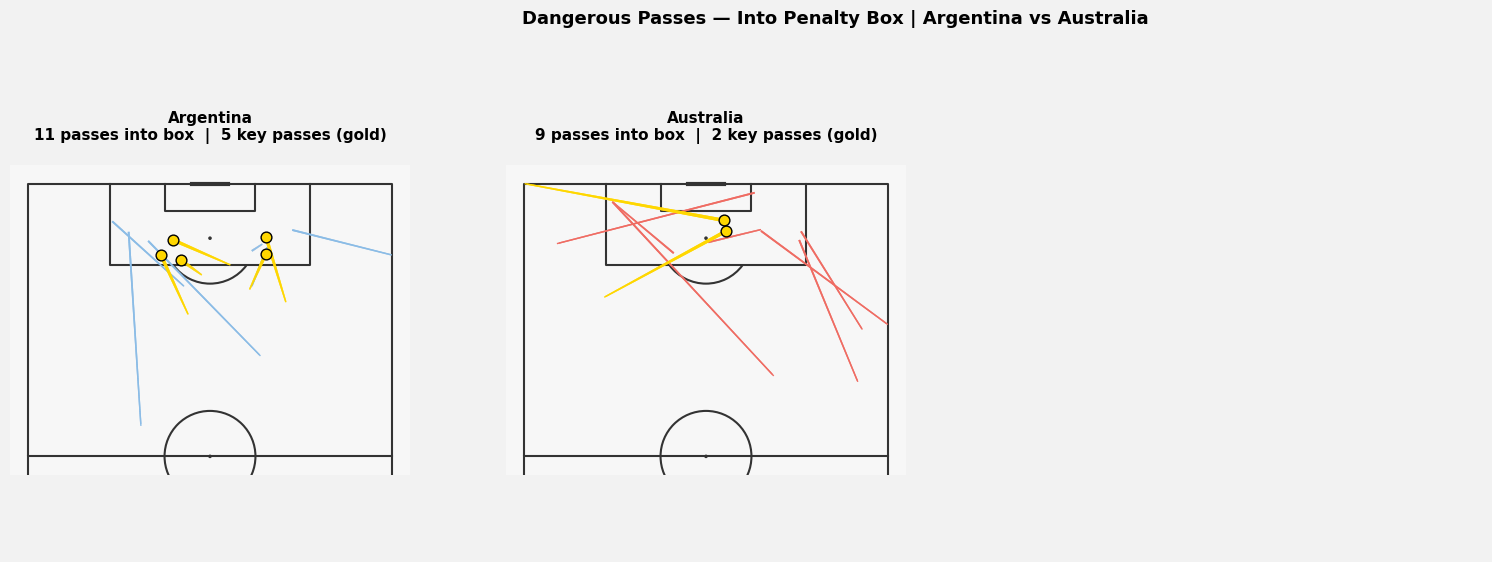

,minute,team,player,pass_recipient,xT_gain
1144,88,Australia,Fran Karačić,Harry Souttar,0.258076
504,34,Argentina,Alexis Mac Allister,Nicolás Hernán Otamendi,0.230775
1128,87,Argentina,Rodrigo Javier De Paul,Lautaro Javier Martínez,0.227563
439,28,Australia,Riley McGree,Harry Souttar,0.215779
881,62,Australia,Craig Goodwin,Mathew Leckie,0.183177
1208,96,Australia,Craig Goodwin,Garang Kuol,0.142527
1200,95,Australia,Fran Karačić,Craig Goodwin,0.034420
161,9,Argentina,Enzo Fernandez,Julián Álvarez,0.032226
268,17,Argentina,Rodrigo Javier De Paul,Lionel Andrés Messi Cuccittini,0.029240
1138,88,Argentina,Lionel Andrés Messi Cuccittini,Lautaro Javier Martínez,0.028932


In [110]:
xt_grid = load_xt_grid()

all_passes = add_xy_columns(
    events[events['type'] == 'Pass'].copy(),
    end_col='pass_end_location'
)

all_passes = all_passes.dropna(subset=['x', 'y', 'end_x', 'end_y'])

all_passes['start_xT'] = all_passes.apply(
    lambda r: xt_value(r.x, r.y, xt_grid), axis=1
)

all_passes['end_xT'] = all_passes.apply(
    lambda r: xt_value(r.end_x, r.end_y, xt_grid), axis=1
)

all_passes['xT_gain'] = (
    all_passes['end_xT'] - all_passes['start_xT']
)

all_passes['completed'] = all_passes['pass_outcome'].isna()

all_passes['shot_assist'] = safe_bool(
    all_passes.get(
        'pass_shot_assist',
        pd.Series(index=all_passes.index)
    )
)

all_passes['goal_assist'] = safe_bool(
    all_passes.get(
        'pass_goal_assist',
        pd.Series(index=all_passes.index)
    )
)

all_passes['final_third_entry'] = (
    all_passes['completed']
    & (all_passes['x'] < 80)
    & (all_passes['end_x'] >= 80)
)

all_passes['high_xt'] = (
    all_passes['completed']
    & (
        all_passes['xT_gain']
        >= all_passes['xT_gain'].quantile(0.92)
    )
)

# =========================================
# NEW DANGEROUS PASS FILTER
# =========================================

dangerous = all_passes[
    all_passes['completed']
    & (all_passes['end_x'] >= 102)
    & (all_passes['end_y'].between(18, 62))
].copy()

dangerous['key_pass'] = dangerous['shot_assist']

# =========================================
# SUMMARY
# =========================================

danger_summary = dangerous.groupby('team').agg(
    Box_Entries=('team', 'size'),
    Key_Passes=('key_pass', 'sum')
).reindex(TEAMS).fillna(0).astype(int)

display(danger_summary)

# =========================================
# SPLIT TEAM DATA
# =========================================

home_df = dangerous[dangerous['team'] == HOME_TEAM]
away_df = dangerous[dangerous['team'] == AWAY_TEAM]

# =========================================
# FIGURE
# =========================================

from mplsoccer import VerticalPitch

fig = plt.figure(figsize=(16, 8), facecolor='#f2f2f2')


fig.text(
    0.37,
    0.84,
    f'Dangerous Passes — Into Penalty Box | {MATCH_LABEL}',
    fontsize=13,
    fontweight='bold'
)

# =========================================
# PITCH STYLE
# =========================================

pitch = VerticalPitch(
    pitch_type='statsbomb',
    half=True,
    pitch_color='#f7f7f7',
    line_color='#333333',
    linewidth=1.5
)

# =========================================
# LEFT PITCH
# =========================================

ax1 = fig.add_axes([0.05, 0.18, 0.25, 0.58])

pitch.draw(ax=ax1)

normal_home = home_df[~home_df['key_pass']]
key_home = home_df[home_df['key_pass']]

pitch.lines(
    normal_home['x'],
    normal_home['y'],
    normal_home['end_x'],
    normal_home['end_y'],
    color='#8bbce6',
    lw=1.3,
    comet=True,
    ax=ax1
)

pitch.lines(
    key_home['x'],
    key_home['y'],
    key_home['end_x'],
    key_home['end_y'],
    color='gold',
    lw=2.5,
    comet=True,
    ax=ax1
)

pitch.scatter(
    key_home['end_x'],
    key_home['end_y'],
    s=60,
    color='gold',
    edgecolors='black',
    zorder=5,
    ax=ax1
)

ax1.set_title(
    f'{HOME_TEAM}\n'
    f'{danger_summary.loc[HOME_TEAM, "Box_Entries"]} passes into box'
    f'  |  '
    f'{danger_summary.loc[HOME_TEAM, "Key_Passes"]} key passes (gold)',
    fontsize=11,
    fontweight='bold',
    pad=18
)

# =========================================
# RIGHT PITCH
# =========================================

ax2 = fig.add_axes([0.36, 0.18, 0.25, 0.58])

pitch.draw(ax=ax2)

normal_away = away_df[~away_df['key_pass']]
key_away = away_df[away_df['key_pass']]

pitch.lines(
    normal_away['x'],
    normal_away['y'],
    normal_away['end_x'],
    normal_away['end_y'],
    color='#ef6c63',
    lw=1.3,
    comet=True,
    ax=ax2
)

pitch.lines(
    key_away['x'],
    key_away['y'],
    key_away['end_x'],
    key_away['end_y'],
    color='gold',
    lw=2.5,
    comet=True,
    ax=ax2
)

pitch.scatter(
    key_away['end_x'],
    key_away['end_y'],
    s=60,
    color='gold',
    edgecolors='black',
    zorder=5,
    ax=ax2
)

ax2.set_title(
    f'{AWAY_TEAM}\n'
    f'{danger_summary.loc[AWAY_TEAM, "Box_Entries"]} passes into box'
    f'  |  '
    f'{danger_summary.loc[AWAY_TEAM, "Key_Passes"]} key passes (gold)',
    fontsize=11,
    fontweight='bold',
    pad=18
)

# =========================================
# RIGHT TEXT PANEL
# =========================================

ax_text = fig.add_axes([0.67, 0.18, 0.30, 0.58])

ax_text.axis('off')

'''ax_text.text(
    0,
    0.85,
    'What counts as dangerous?',
    fontsize=22,
    fontweight='bold',
    color='darkred'
)

ax_text.text(
    0,
    0.58,
    "Any pass whose end-point lands inside the\n"
    "opponent's penalty box.\n"
    "Gold lines = key passes\n"
    "(pass immediately before a shot).",
    fontsize=17,
    linespacing=1.5
)

ax_text.text(
    0,
    0.38,
    'The numbers',
    fontsize=22,
    fontweight='bold',
    color='darkred'
)'''
'''ax_text.text(
    0.02,
    0.05,
    f'• {HOME_TEAM}: '
    f'{danger_summary.loc[HOME_TEAM, "Box_Entries"]} box entries, '
    f'{danger_summary.loc[HOME_TEAM, "Key_Passes"]} key passes.\n\n'

    f'• {AWAY_TEAM}: '
    f'{danger_summary.loc[AWAY_TEAM, "Box_Entries"]} box entries, '
    f'{danger_summary.loc[AWAY_TEAM, "Key_Passes"]} key passes.\n\n'

    f'• {HOME_TEAM} created more dangerous\n'
    f'  attacking situations.',
    
    fontsize=17,
    linespacing=1.7
)
'''
plt.show()

dangerous[
    ['minute', 'team', 'player',
     'pass_recipient', 'xT_gain']
].sort_values(
    'xT_gain',
    ascending=False
).head(12)

**Interpretation:** Argentina produced more final-third entries and a broader dangerous-pass map. Australia still appears through direct passes and high-xT moments, but the volume difference supports the wider story of Argentina controlling more useful possession.


## 7. xT Analysis

**How to read this chart:** the left pitch is the xT surface itself: each cell estimates the value of possessing the ball there. The Argentina and Australia panels show where each team actually created positive xT through completed pass destinations.


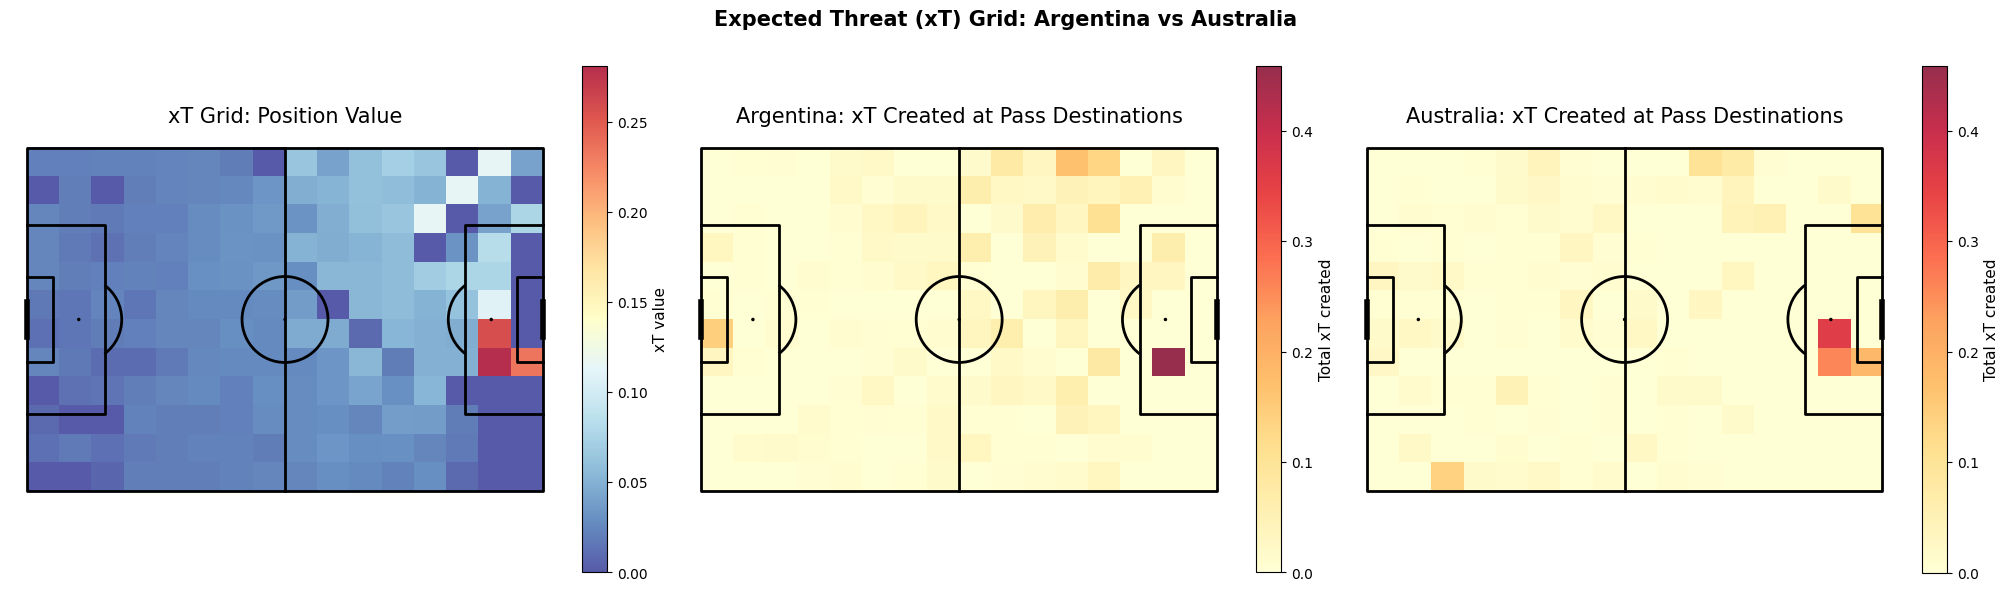

,Positive pass xT,Positive carry xT
team,,
Argentina,3.27,1.92
Australia,2.34,0.76


,team,player,Player positive pass xT
0,Argentina,Alexis Mac Allister,0.521420
1,Australia,Harry Souttar,0.418142
2,Argentina,Enzo Fernandez,0.411946
3,Argentina,Rodrigo Javier De Paul,0.410687
4,Argentina,Lionel Andrés Messi Cuccittini,0.344565
5,Australia,Fran Karačić,0.340894
6,Australia,Craig Goodwin,0.336791
7,Argentina,Cristian Gabriel Romero,0.336651
8,Argentina,Nicolás Hernán Otamendi,0.289184
9,Australia,Riley McGree,0.254292


In [78]:
completed_passes = all_passes[all_passes['completed']].copy()
positive_xt = completed_passes[completed_passes['xT_gain'] > 0].copy()
player_xt = positive_xt.groupby(['team', 'player'])['xT_gain'].sum().sort_values(ascending=False).head(12)
team_xt = positive_xt.groupby('team')['xT_gain'].sum().reindex(TEAMS).fillna(0).sort_values(ascending=False)

carries_for_xt = add_xy_columns(events[events['type'] == 'Carry'].copy(), end_col='carry_end_location')
carries_for_xt = carries_for_xt.dropna(subset=['x', 'y', 'end_x', 'end_y']).copy()
carries_for_xt['start_xT'] = carries_for_xt.apply(lambda r: xt_value(r.x, r.y, xt_grid), axis=1)
carries_for_xt['end_xT'] = carries_for_xt.apply(lambda r: xt_value(r.end_x, r.end_y, xt_grid), axis=1)
carries_for_xt['xT_gain'] = carries_for_xt['end_xT'] - carries_for_xt['start_xT']
positive_carry_xt = carries_for_xt[carries_for_xt['xT_gain'] > 0].copy()
carry_xt_team = positive_carry_xt.groupby('team')['xT_gain'].sum().reindex(TEAMS).fillna(0)

fig, axs = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)
plot_xt_surface(axs[0], xt_grid, 'xT Grid: Position Value', cmap='RdYlBu_r', label='xT value')

destination_matrices = {}
max_destination_value = 0
for team in TEAMS:
    team_matrix = xt_destination_matrix(positive_xt[positive_xt['team'] == team], xt_grid)
    destination_matrices[team] = team_matrix
    max_destination_value = max(max_destination_value, team_matrix.max())

for ax, team in zip(axs[1:], TEAMS):
    plot_xt_surface(
        ax,
        destination_matrices[team],
        f'{team}: xT Created at Pass Destinations',
        cmap='YlOrRd',
        vmax=max_destination_value if max_destination_value > 0 else None,
        label='Total xT created',
    )

fig.suptitle(f'Expected Threat (xT) Grid: {MATCH_LABEL}', fontsize=15, fontweight='bold')
plt.show()

xt_summary = pd.DataFrame({
    'Positive pass xT': team_xt.reindex(TEAMS),
    'Positive carry xT': carry_xt_team.reindex(TEAMS),
})
display(xt_summary.style.format('{:.2f}'))
display(player_xt.rename('Player positive pass xT').reset_index())


**Interpretation:** The xT surface rises as the ball approaches the goal, while the team destination panels show where value was actually created in this match. Argentina generated more positive pass xT overall, but Australia still created visible value through selected forward passes. Carry xT is also higher for Argentina, showing that their ball progression came through both passing and carrying.


## 8. Zone and Territory Analysis

**How to read this chart:** the pitch is split into nine zones: defensive/middle/attacking thirds by length and left/center/right channels by width. The number in each zone is the count of located team events there.


channel               Left  Center  Right
team      third                          
Argentina Defensive  256.0   240.0  193.0
          Middle     410.0   381.0  424.0
          Attacking  190.0   152.0  197.0
Australia Defensive  231.0   283.0  261.0
          Middle     203.0   144.0  251.0
          Attacking  123.0    79.0  101.0

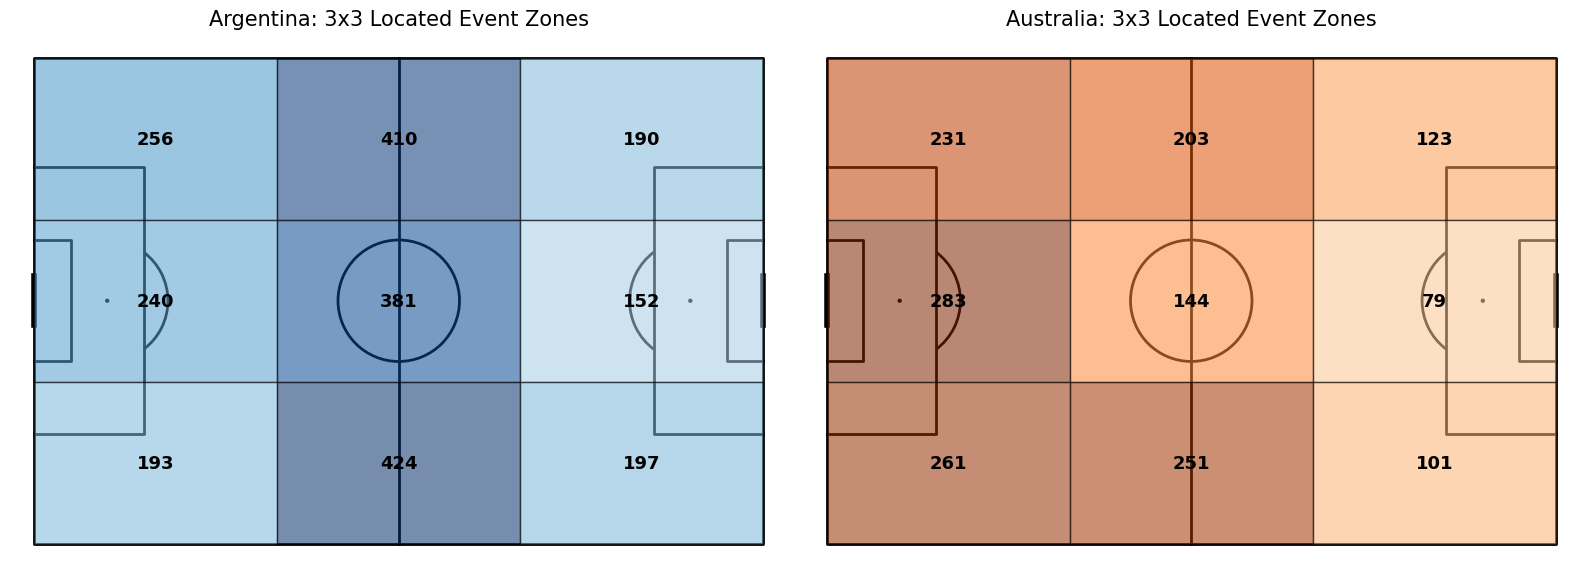

In [79]:
located_events = add_xy_columns(events.dropna(subset=['team']).copy()).dropna(subset=['x', 'y'])
located_events['third'] = pd.cut(located_events['x'], bins=[0, 40, 80, 120], labels=['Defensive', 'Middle', 'Attacking'], include_lowest=True)
located_events['channel'] = pd.cut(located_events['y'], bins=[0, 80/3, 160/3, 80], labels=['Left', 'Center', 'Right'], include_lowest=True)
zone_counts = located_events.groupby(['team', 'third', 'channel'], observed=False).size().rename('Events').reset_index()
zone_table = zone_counts.pivot_table(index=['team', 'third'], columns='channel', values='Events', fill_value=0, observed=False)
display(zone_table)

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axs = pitch.draw(ncols=2, figsize=(16, 7))
axs = np.ravel(axs)
thirds = [('Defensive', 0, 40), ('Middle', 40, 80), ('Attacking', 80, 120)]
channels = [('Left', 0, 80/3), ('Center', 80/3, 160/3), ('Right', 160/3, 80)]

for ax, team in zip(axs, TEAMS):
    team_counts = zone_counts[zone_counts['team'] == team]
    max_count = max(team_counts['Events'].max(), 1)
    for third, x0, x1 in thirds:
        for channel, y0, y1 in channels:
            count_series = team_counts[(team_counts['third'] == third) & (team_counts['channel'] == channel)]['Events']
            count = int(count_series.iloc[0]) if not count_series.empty else 0
            color = plt.cm.Blues(count / max_count) if team == HOME_TEAM else plt.cm.Oranges(count / max_count)
            ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, facecolor=color, edgecolor='black', alpha=0.55, zorder=1))
            ax.text((x0 + x1) / 2, (y0 + y1) / 2, str(count), ha='center', va='center', fontsize=13, weight='bold', zorder=2)
    ax.set_title(f'{team}: 3x3 Located Event Zones')
plt.show()


**Interpretation:** Argentina’s territory counts are heavier through possession zones and attacking areas, while Australia’s counts reflect deeper build-up and defensive circulation. The 3x3 grid makes the territorial balance visible without depending on one player or one action type.


## 9. Pitch Control Approximation from StatsBomb 360

**How to read these charts:** each panel uses the highest-xG shot with matching 360 freeze-frame data for that team. Warmer/cooler space indicates the simplified local control balance around nearby players at the shot moment; the star marks the shot location.


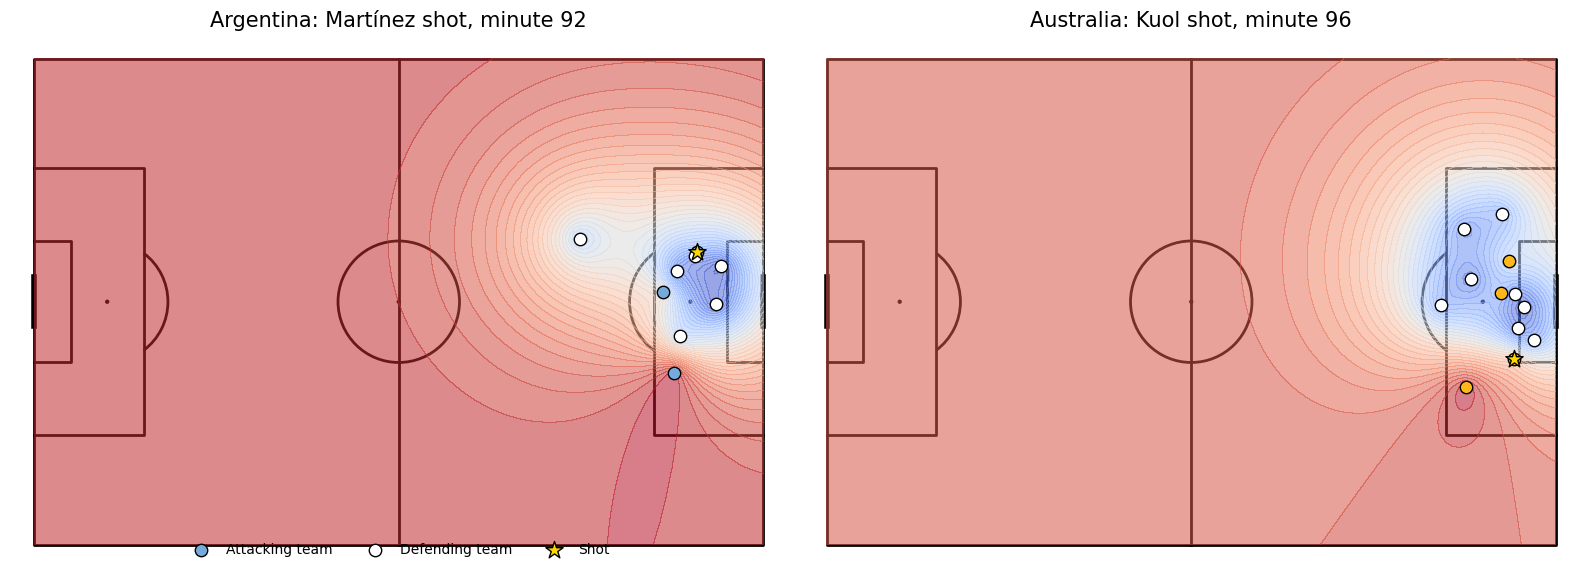

,Team,Player,Minute,xG
0,Argentina,Lautaro Javier Martínez,92,0.37
1,Australia,Garang Kuol,96,0.23


In [80]:
def frame_rows_for_event(frames_df, event_id):
    if frames_df.empty or 'id' not in frames_df.columns:
        return pd.DataFrame(columns=['x', 'y', 'teammate', 'actor', 'keeper'])
    frame_players = frames_df[frames_df['id'] == event_id].copy()
    if frame_players.empty:
        return pd.DataFrame(columns=['x', 'y', 'teammate', 'actor', 'keeper'])
    frame_players['x'] = frame_players['location'].apply(lambda v: first_coord(v, 0))
    frame_players['y'] = frame_players['location'].apply(lambda v: first_coord(v, 1))
    return frame_players.dropna(subset=['x', 'y'])


def plot_pitch_control_for_shot(ax, candidate_shot):
    frame_players = frame_rows_for_event(frames, candidate_shot['id'])
    if frame_players.empty:
        ax.text(60, 40, 'No frame players', ha='center', va='center')
        return
    x_grid = np.linspace(0, 120, 121)
    y_grid = np.linspace(0, 80, 81)
    xx, yy = np.meshgrid(x_grid, y_grid)
    control = np.zeros_like(xx, dtype=float)

    for _, p in frame_players.iterrows():
        dist = np.sqrt((xx - p.x) ** 2 + (yy - p.y) ** 2)
        influence = np.exp(-dist / 10)
        control += influence if bool(p.teammate) else -influence

    ax.contourf(xx, yy, control, levels=40, cmap='coolwarm', alpha=0.55)
    attackers = frame_players[frame_players['teammate'].astype(bool)]
    defenders = frame_players[~frame_players['teammate'].astype(bool)]
    pitch.scatter(attackers['x'], attackers['y'], s=80, color=TEAM_COLORS.get(candidate_shot['team'], '#75AADB'), edgecolors='black', ax=ax, label='Attacking team')
    pitch.scatter(defenders['x'], defenders['y'], s=80, color='white', edgecolors='black', ax=ax, label='Defending team')
    pitch.scatter(candidate_shot['x'], candidate_shot['y'], s=170, marker='*', color='gold', edgecolors='black', ax=ax, label='Shot')
    ax.set_title(f"{candidate_shot['team']}: {candidate_shot['player'].split()[-1]} shot, minute {int(candidate_shot['minute'])}")

shot_ids_with_frames = set(frames['id']) if not frames.empty and 'id' in frames.columns else set()
shot_candidates = shots[shots['id'].isin(shot_ids_with_frames)].sort_values('shot_statsbomb_xg', ascending=False)

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, axs = pitch.draw(ncols=2, figsize=(16, 7))
axs = np.ravel(axs)
pc_summary = []
for ax, team in zip(axs, TEAMS):
    team_candidates = shot_candidates[shot_candidates['team'] == team]
    if team_candidates.empty:
        ax.text(60, 40, f'No framed shot for {team}', ha='center', va='center')
        ax.set_title(f'{team}: no framed shot')
    else:
        candidate = team_candidates.iloc[0]
        pc_summary.append({'Team': team, 'Player': candidate['player'], 'Minute': candidate['minute'], 'xG': candidate['shot_statsbomb_xg']})
        plot_pitch_control_for_shot(ax, candidate)
axs[0].legend(frameon=False, loc='lower center', ncol=3)
plt.show()

display(pd.DataFrame(pc_summary).style.format({'xG': '{:.2f}'}))


**Interpretation:** Showing one framed shot for each team makes the 360 section balanced. Argentina’s panel captures the spacing around one of its higher-value chances, while Australia’s panel shows the pressure context around its best framed opportunity.


## 10. Ball Carries — Distance & Speed

**How to read these charts:** the left chart answers who carried the ball the farthest in total. The right chart uses the same players and answers who moved the ball fastest while carrying. Speed is estimated from event duration, so it is event-derived carry speed rather than tracking-data sprint speed.


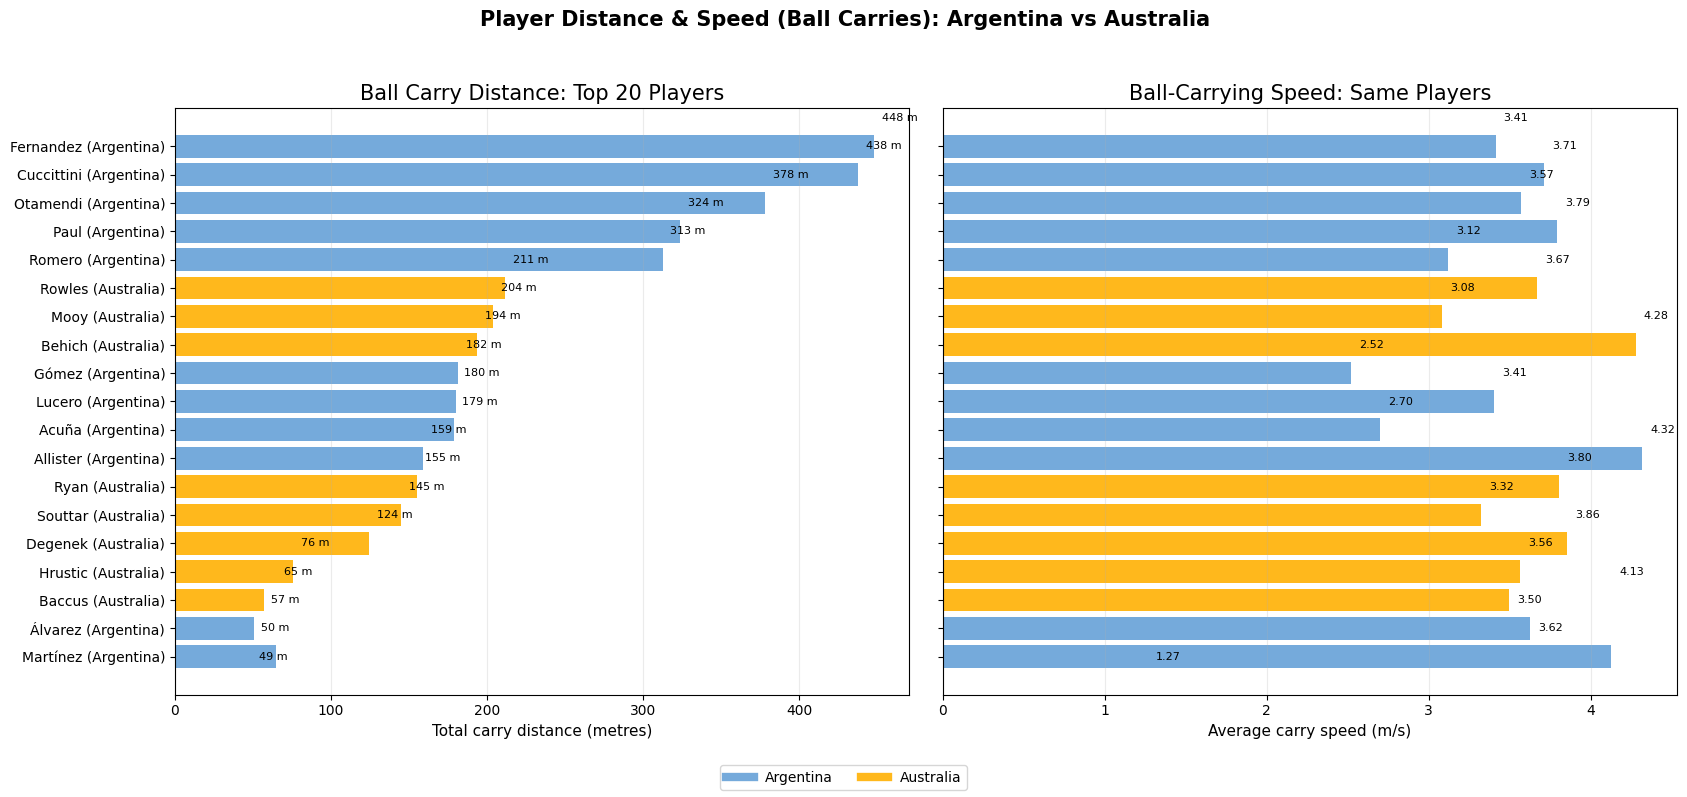

,team,player,total_distance_m,carries,avg_speed_mps
0,Argentina,Enzo Fernandez,448.2,68,3.41
1,Argentina,Lionel Andrés Messi Cuccittini,438.0,54,3.71
2,Argentina,Nicolás Hernán Otamendi,378.2,65,3.57
3,Argentina,Rodrigo Javier De Paul,323.6,57,3.79
4,Argentina,Cristian Gabriel Romero,312.5,49,3.12
5,Australia,Kye Rowles,211.4,41,3.67
6,Australia,Aaron Mooy,203.7,33,3.08
7,Australia,Aziz Eraltay Behich,193.7,26,4.28
8,Argentina,Alejandro Darío Gómez,181.7,30,2.52
9,Argentina,Nahuel Molina Lucero,180.4,30,3.41


action,Progressive carry,Progressive pass
team,,
Argentina,21,35
Australia,9,40


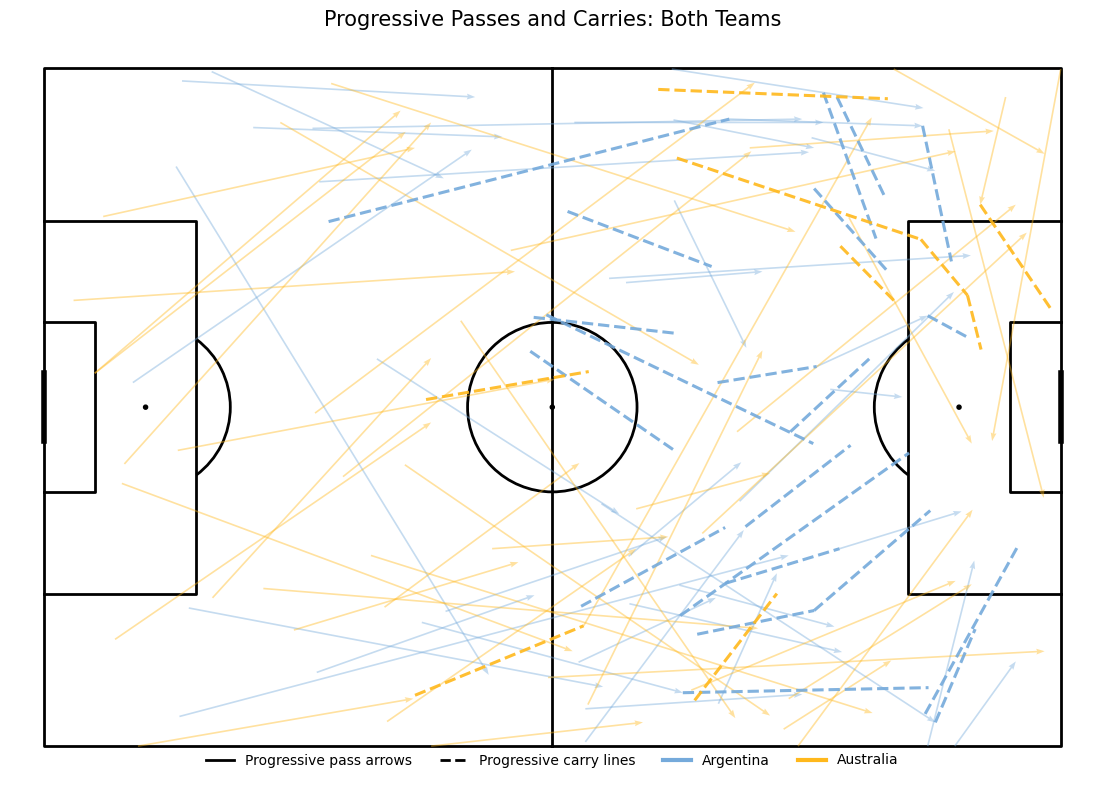

In [81]:
carry_metrics = compute_carry_metrics(events)
carry_player_metrics = (
    carry_metrics.groupby(['team', 'player'])
    .agg(
        total_distance_m=('distance_m', 'sum'),
        carries=('id', 'count'),
        avg_speed_mps=('speed_mps', 'mean'),
    )
    .sort_values('total_distance_m', ascending=False)
)
top_carry_players = carry_player_metrics.head(20).copy()

fig, axs = plt.subplots(1, 2, figsize=(17, 8), sharey=True)
plot_df = top_carry_players.iloc[::-1]
labels = [f'{player.split()[-1]} ({team})' for team, player in plot_df.index]
colors = [TEAM_COLORS.get(team, 'grey') for team, player in plot_df.index]

axs[0].barh(labels, plot_df['total_distance_m'], color=colors)
axs[0].set_title('Ball Carry Distance: Top 20 Players')
axs[0].set_xlabel('Total carry distance (metres)')
axs[0].grid(axis='x', alpha=0.25)
for idx, value in enumerate(plot_df['total_distance_m']):
    axs[0].text(value + 5, idx, f'{value:.0f} m', va='center', fontsize=8)

axs[1].barh(labels, plot_df['avg_speed_mps'], color=colors)
axs[1].set_title('Ball-Carrying Speed: Same Players')
axs[1].set_xlabel('Average carry speed (m/s)')
axs[1].grid(axis='x', alpha=0.25)
for idx, value in enumerate(plot_df['avg_speed_mps']):
    axs[1].text(value + 0.05, idx, f'{value:.2f}', va='center', fontsize=8)

legend_items = [
    Line2D([0], [0], color=TEAM_COLORS[HOME_TEAM], lw=6, label=HOME_TEAM),
    Line2D([0], [0], color=TEAM_COLORS[AWAY_TEAM], lw=6, label=AWAY_TEAM),
]
fig.legend(handles=legend_items, loc='lower center', ncol=2, frameon=True)
fig.suptitle(f'Player Distance & Speed (Ball Carries): {MATCH_LABEL}', fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

display(top_carry_players.reset_index().style.format({
    'total_distance_m': '{:.1f}',
    'avg_speed_mps': '{:.2f}',
}))

progressive_passes = completed_passes.copy()
progressive_passes['start_dist'] = distance_to_goal(progressive_passes['x'], progressive_passes['y'])
progressive_passes['end_dist'] = distance_to_goal(progressive_passes['end_x'], progressive_passes['end_y'])
progressive_passes['progress_pct'] = (progressive_passes['start_dist'] - progressive_passes['end_dist']) / progressive_passes['start_dist']
progressive_passes = progressive_passes[progressive_passes['progress_pct'] >= 0.25]

carries = add_xy_columns(events[events['type'] == 'Carry'].copy(), end_col='carry_end_location')
carries = carries.dropna(subset=['x', 'y', 'end_x', 'end_y'])
carries['start_dist'] = distance_to_goal(carries['x'], carries['y'])
carries['end_dist'] = distance_to_goal(carries['end_x'], carries['end_y'])
carries['progress_pct'] = (carries['start_dist'] - carries['end_dist']) / carries['start_dist']
progressive_carries = carries[carries['progress_pct'] >= 0.25]

progress_summary = pd.concat([
    progressive_passes.assign(action='Progressive pass'),
    progressive_carries.assign(action='Progressive carry')
]).groupby(['team', 'action']).size().unstack(fill_value=0).reindex(TEAMS).fillna(0).astype(int)
display(progress_summary)

pitch = Pitch(pitch_type='statsbomb', pitch_color='white', line_color='black')
fig, ax = pitch.draw(figsize=(13, 8))

for team, df_team in progressive_passes.groupby('team'):
    pitch.arrows(df_team['x'], df_team['y'], df_team['end_x'], df_team['end_y'],
                 width=1.2, headwidth=3.5, color=TEAM_COLORS.get(team, 'grey'), alpha=0.42, ax=ax)
for team, df_team in progressive_carries.groupby('team'):
    pitch.lines(df_team['x'], df_team['y'], df_team['end_x'], df_team['end_y'],
                lw=2.2, color=TEAM_COLORS.get(team, 'grey'), alpha=0.9, ax=ax, linestyle='--')

legend_items = [
    Line2D([0], [0], color='black', lw=2, label='Progressive pass arrows'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='Progressive carry lines'),
    Line2D([0], [0], color=TEAM_COLORS[HOME_TEAM], lw=3, label=HOME_TEAM),
    Line2D([0], [0], color=TEAM_COLORS[AWAY_TEAM], lw=3, label=AWAY_TEAM),
]
ax.legend(handles=legend_items, frameon=False, loc='lower center', ncol=4)
ax.set_title('Progressive Passes and Carries: Both Teams')
plt.show()


**Interpretation:** The distance chart identifies heavy ball-carriers, while the speed chart separates steady recyclers from players who moved the ball more decisively when carrying. Argentina’s top carry-distance players are mostly possession connectors, while Australia’s quickest carriers point to more direct ball progression from fewer carry events. The progressive-action map then adds the spatial direction behind those carry and pass totals.


## Tactical Conclusions

Argentina controlled the match profile across the main indicators: 14 shots to 5, 1.48 xG to 0.43, 646 completed passes to 384, and 45 final-third entries to 23. The passing networks, multi-player heatmaps, xT chart, and progressive-action map all point to a team that repeatedly moved the ball into useful areas through connected possession.

Australia’s analysis is visible in every section. Their network and heatmaps show deeper defensive/build-up involvement, their dangerous-pass and xT moments show more selective forward threat, and their pitch-control panel gives a matched 360 view of one chance context. The 2-1 scoreline reflects Australia staying alive through organization and the late own-goal/deflection sequence, even though the event-level attacking indicators favor Argentina.

Overall, the notebook supports a two-team tactical reading: Argentina generated the clearer and more stable attacking structure, while Australia competed through compactness, defensive volume, and direct late pressure.
